In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [2]:
no2 = pd.read_csv("./data/NO2_manual_1213m.csv")
wind_u = pd.read_csv("./data/WIND_U_manual_27929m.csv")
wind_v = pd.read_csv("./data/WIND_V_manual_27929m.csv")
temp = pd.read_csv("./data/TEMP_manual_27929m.csv")
co = pd.read_csv("./data/CO_manual_1213m.csv")

In [3]:
# print unique (latitude, longitude) pairs in temp
unique_latlon = (
    temp[["latitude", "longitude"]]
    .dropna()
    .drop_duplicates()
    .sort_values(["latitude", "longitude"])
    .reset_index(drop=True)
)
print(f"Unique lat-long pairs: {len(unique_latlon)}")
print(unique_latlon.to_string(index=False))

Unique lat-long pairs: 16
 latitude  longitude
28.278565  77.171222
28.278565  77.422121
28.278565  77.673019
28.278565  77.923917
28.529464  77.171222
28.529464  77.422121
28.529464  77.673019
28.529464  77.923917
28.780362  77.171222
28.780362  77.422121
28.780362  77.673019
28.780362  77.923917
29.031260  77.171222
29.031260  77.422121
29.031260  77.673019
29.031260  77.923917


This is the code I used to fetch the elevation data for each of the lat longs and add them to the no2 dataset

In [5]:
import requests


def fetch_elevations(batch, session):
    url = "https://api.open-elevation.com/api/v1/lookup"
    payload = {
        "locations": [
            {"latitude": latitude, "longitude": longitude} for latitude, longitude in batch
        ]
    }
    response = session.post(url, json=payload, timeout=60)
    response.raise_for_status()
    return response.json()["results"]


if "elevation" not in no2.columns:
    no2["elevation"] = np.nan

existing_elevation_lookup = (
    no2.loc[no2["elevation"].notna(), ["latitude", "longitude", "elevation"]]
    .drop_duplicates(subset=["latitude", "longitude"])
    .set_index(["latitude", "longitude"])["elevation"]
    .to_dict()
)

unique_coordinates = no2.loc[
    ~no2.set_index(["latitude", "longitude"]).index.isin(existing_elevation_lookup.keys()),
    ["latitude", "longitude"],
].drop_duplicates().copy()

session = requests.Session()
elevation_lookup = dict(existing_elevation_lookup)
batch_size = 500

for start in range(0, len(unique_coordinates), batch_size):
    batch_frame = unique_coordinates.iloc[start:start + batch_size][["latitude", "longitude"]]
    batch = list(batch_frame.itertuples(index=False, name=None))
    try:
        results = fetch_elevations(batch, session)
        for (latitude, longitude), result in zip(batch, results):
            elevation_lookup[(latitude, longitude)] = result["elevation"]
    except requests.RequestException as exc:
        print(f"Elevation lookup failed for batch starting at row {start}: {exc}")
        for latitude, longitude in batch:
            elevation_lookup[(latitude, longitude)] = np.nan

    no2["elevation"] = [
        elevation_lookup.get((latitude, longitude), np.nan)
        for latitude, longitude in no2[["latitude", "longitude"]].itertuples(index=False, name=None)
    ]
    no2.to_csv("./data/NO2_manual_1213m.csv", index=False)

    print(f"Processed batch {start // batch_size + 1} / {(len(unique_coordinates) + batch_size - 1) // batch_size} and checkpointed ./data/NO2_manual_1213m.csv.")
    print(no2[["latitude", "longitude", "elevation"]].head())

print(f"Filled elevation for {len(unique_coordinates)} previously missing unique latitude/longitude pairs.")

Filled elevation for 0 previously missing unique latitude/longitude pairs.


In [3]:
def _get_station_grid_lookup(weather_df):
    cache_key = "_station_grid_lookup"
    cached = weather_df.attrs.get(cache_key)
    if cached is not None:
        return cached

    station_latitudes = np.sort(weather_df["latitude"].dropna().unique())
    station_longitudes = np.sort(weather_df["longitude"].dropna().unique())

    if len(station_latitudes) == 0 or len(station_longitudes) == 0:
        raise ValueError("weather_df must contain at least one valid latitude and longitude.")

    lat_bounds = np.concatenate(([-np.inf], (station_latitudes[:-1] + station_latitudes[1:]) / 2, [np.inf]))
    lon_bounds = np.concatenate(([-np.inf], (station_longitudes[:-1] + station_longitudes[1:]) / 2, [np.inf]))

    cached = (station_latitudes, station_longitudes, lat_bounds, lon_bounds)
    weather_df.attrs[cache_key] = cached
    return cached


def _nearest_station_coordinate(value, station_values, bounds):
    station_index = np.searchsorted(bounds, value, side="right") - 1
    station_index = int(np.clip(station_index, 0, len(station_values) - 1))
    return station_values[station_index]


def _get_daily_station_cache(weather_df, col):
    cache_key = f"_daily_station_cache::{col}"
    cached = weather_df.attrs.get(cache_key)
    if cached is not None:
        return cached

    timestamps = weather_df.attrs.get("_timestamp_cache")
    if timestamps is None or len(timestamps) != len(weather_df):
        timestamps = pd.to_datetime(weather_df["timestamp"], errors="coerce")
        weather_df.attrs["_timestamp_cache"] = timestamps

    valid_rows = timestamps.notna() & weather_df[col].notna() & weather_df["latitude"].notna() & weather_df["longitude"].notna()
    daily_station_cache = {}

    if valid_rows.any():
        day_values = timestamps.loc[valid_rows].dt.normalize()
        valid_frame = weather_df.loc[valid_rows, ["latitude", "longitude", col]].copy()
        valid_frame["day"] = day_values.values
        grouped = (
            valid_frame.groupby(["day", "latitude", "longitude"], as_index=False)[col]
            .mean()
        )

        for day, day_frame in grouped.groupby("day", sort=False):
            daily_station_cache[pd.Timestamp(day)] = day_frame.set_index(["latitude", "longitude"])[col].to_dict()

    weather_df.attrs[cache_key] = daily_station_cache
    return daily_station_cache


def get_avg_weather_for_closest_latlong(latitude, longitude, date, weather_df, col):
    date = pd.to_datetime(date)
    day_start = date.normalize()

    if "timestamp" not in weather_df.columns:
        raise KeyError("weather_df must contain a 'timestamp' column.")
    if col not in weather_df.columns:
        raise KeyError(f"{col} not found in weather_df columns.")

    station_latitudes, station_longitudes, lat_bounds, lon_bounds = _get_station_grid_lookup(weather_df)
    closest_latitude = _nearest_station_coordinate(latitude, station_latitudes, lat_bounds)
    closest_longitude = _nearest_station_coordinate(longitude, station_longitudes, lon_bounds)

    daily_station_cache = _get_daily_station_cache(weather_df, col)
    day_values = daily_station_cache.get(day_start)

    if day_values is None:
        raise ValueError(f"No weather data found for date {day_start.date()}.")

    station_value = day_values.get((closest_latitude, closest_longitude))
    if station_value is not None and not pd.isna(station_value):
        return station_value

    day_mask = pd.to_datetime(weather_df["timestamp"], errors="coerce").dt.normalize().eq(day_start)
    daily_weather = weather_df.loc[day_mask, ["latitude", "longitude", col]].dropna(subset=[col])
    if daily_weather.empty:
        raise ValueError(f"No usable weather values found for date {day_start.date()}.")

    distance = (daily_weather[["latitude", "longitude"]] - [latitude, longitude]).abs().sum(axis=1)
    closest_idx = distance.idxmin()
    return daily_weather.loc[closest_idx, col]


wind_u["timestamp"] = pd.to_datetime(wind_u["timestamp"], errors="coerce")
temp["timestamp"] = pd.to_datetime(temp["timestamp"], errors="coerce")
# 28.219475044486515,77.1511982864422,192.0,2019-01-09
print(get_avg_weather_for_closest_latlong(29.219475044486515, 79.2011985864423, "2019-01-09", temp, "TEMP"))


286.45952916666664


Below is the code I used to visualize how the temperature stations are located across my ROI, and what latlongs i have no2 data for (from a random days image)(also shows missingness on that day, but that is an aside)

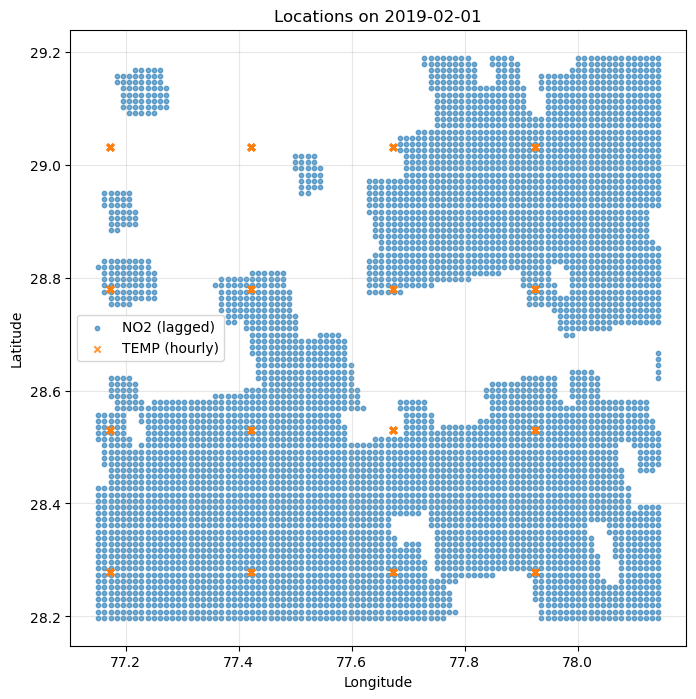

In [20]:
# plot lat/lon points from no2_lagged_df and temp for a single day
selected_day = pd.to_datetime("2019-02-01").normalize()

# ensure temp timestamps are datetimes
temp["timestamp"] = pd.to_datetime(temp["timestamp"], errors="coerce")
temp_day = temp[temp["timestamp"].dt.normalize() == selected_day]

no2_day = no2[pd.to_datetime(no2["timestamp"]).dt.normalize() == selected_day]

plt.figure(figsize=(8, 8))
plt.scatter(no2_day["longitude"], no2_day["latitude"], s=10, c="C0", alpha=0.6, label="NO2 (lagged)")
plt.scatter(temp_day["longitude"], temp_day["latitude"], s=20, c="C1", marker="x", alpha=0.8, label="TEMP (hourly)")
plt.title(f"Locations on {selected_day.date()}")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.gca().set_aspect("equal", adjustable="box") 
plt.grid(alpha=0.3)
plt.show()

# Section 1: Data preprocessing 

first we establish the lagged dataset, which involves creating new features based on previous time steps of the data. For example, if we have a time series, we can create lagged features such as the n02 at time t-1, t-2, etc. This hopefully will allow us to capture the temporal dependencies in the data.

Now, we create the lagged dataset. We will add the no2 values from the previous 7 days and the elevation and temperature values of current day as features to predict the no2 value of the next day.

In [23]:
# adding nearest temp reading to the dataset

from tqdm.auto import tqdm

date_column = "timestamp"

no2[date_column] = pd.to_datetime(no2[date_column], errors="coerce")
no2 = no2.dropna(subset=[date_column]).copy()
no2["day"] = no2[date_column].dt.normalize()

value_column = "NO2"
# Compute TEMP once per unique (latitude, longitude, day) and merge it back into no2.
unique_day_locs = no2[["latitude", "longitude", "day"]].drop_duplicates().reset_index(drop=True)

temps = []
for lat, lon, day in tqdm(
    unique_day_locs.itertuples(index=False, name=None),
    total=len(unique_day_locs),
    desc="Computing TEMP for unique (lat,lon,day)",
):
    try:
        val = get_avg_weather_for_closest_latlong(lat, lon, day, temp, "TEMP")
    except Exception:
        val = np.nan
    temps.append(val)

unique_day_locs["TEMP"] = temps
no2 = no2.merge(unique_day_locs, on=["latitude", "longitude", "day"], how="left")

print(f"Attached TEMP to no2 for {len(unique_day_locs)} unique (lat, lon, day) rows.")
no2[["latitude", "longitude", "day", "TEMP"]].head()

Computing TEMP for unique (lat,lon,day):   0%|          | 0/13465772 [00:00<?, ?it/s]

Attached TEMP to no2 for 13465772 unique (lat, lon, day) rows.


,latitude,longitude,day,TEMP
0,28.197678,77.151198,2019-01-01,NaN
1,28.197678,77.162097,2019-01-01,NaN
2,28.197678,77.172995,2019-01-01,NaN
3,28.197678,77.183893,2019-01-01,NaN
4,28.197678,77.194792,2019-01-01,NaN


In [25]:
daily_no2 = (
    no2.groupby(["latitude", "longitude", "timestamp"], as_index=False)
    .agg(
        no2=("NO2", "mean"),
        TEMP=("TEMP", "mean"),
    )
)

if "elevation" in no2.columns:
    elevation_by_location = (
        no2[["latitude", "longitude", "elevation"]]
        .dropna(subset=["latitude", "longitude"])
        .drop_duplicates(subset=["latitude", "longitude"])
    )
    daily_no2 = daily_no2.merge(elevation_by_location, on=["latitude", "longitude"], how="left")
else:
    daily_no2["elevation"] = np.nan

daily_no2 = daily_no2.sort_values(["latitude", "longitude", "timestamp"]).reset_index(drop=True)

lag_columns = []
for lag in range(0, 8):
    column_name = f"no2_day{lag}"
    daily_no2[column_name] = daily_no2.groupby(["latitude", "longitude"])["no2"].shift(lag)
    lag_columns.append(column_name)

no2_lagged_df = daily_no2.rename(columns={"timestamp": "timestamp"})[
    ["latitude", "longitude", "elevation", "timestamp"] + lag_columns
].dropna(subset=lag_columns).reset_index(drop=True)

print(f"Created lagged NO2 dataset with shape: {no2_lagged_df.shape}")
no2_lagged_df.head()

Created lagged NO2 dataset with shape: (13858360, 12)


,latitude,longitude,elevation,timestamp,no2_day0,no2_day1,no2_day2,no2_day3,no2_day4,no2_day5,no2_day6,no2_day7
0,28.197678,77.151198,NaN,2019-01-09 07:54:00,0.000062,0.000057,0.000073,0.000048,0.000052,0.000057,0.000042,0.000102
1,28.197678,77.151198,NaN,2019-01-10 07:35:00,0.000076,0.000062,0.000057,0.000073,0.000048,0.000052,0.000057,0.000042
2,28.197678,77.151198,NaN,2019-01-11 07:16:00,0.000086,0.000076,0.000062,0.000057,0.000073,0.000048,0.000052,0.000057
3,28.197678,77.151198,NaN,2019-01-12 06:57:00,0.000033,0.000086,0.000076,0.000062,0.000057,0.000073,0.000048,0.000052
4,28.197678,77.151198,NaN,2019-01-14 08:01:00,0.000071,0.000033,0.000086,0.000076,0.000062,0.000057,0.000073,0.000048


In [26]:
no2_lagged_df = no2_lagged_df.sort_values(["timestamp", "latitude", "longitude"]).reset_index(drop=True)


In [27]:
no2_lagged_df.to_csv("./data/no2_lagged.csv", index=False)

below is code to visualise monthly heatmaps of the no2 data

In [34]:
def monthly_heatmaps(no2_lagged_df=no2_lagged_df, plot_col="no2_day0", selected_datetime=pd.to_datetime("2019-02-01")):
    # Validate column
    if plot_col not in no2_lagged_df.columns:
        raise KeyError(f"{plot_col} not found in no2_lagged_df columns.")

    # Ensure datetime is normalized (date-only) for reliable filtering
    no2_lagged_df["timestamp"] = pd.to_datetime(no2_lagged_df["timestamp"]).dt.normalize()

    # If selected date is outside available range, snap to nearest available date
    available_dates = no2_lagged_df["timestamp"].dropna().sort_values().unique()
    if len(available_dates) == 0:
        raise ValueError("no2_lagged_df has no valid timestamp values.")

    nearest_datetime = min(available_dates, key=lambda d: abs(d - selected_datetime.to_datetime64()))
    nearest_datetime = pd.to_datetime(nearest_datetime)

    # Build month window from nearest date (fixes empty month issue like 2020-01 for 2019-only data)
    month_start = nearest_datetime.to_period("M").to_timestamp()
    month_end = month_start + pd.offsets.MonthEnd(1)
    all_days = pd.date_range(month_start, month_end, freq="D")

    # Data for this month
    month_df = no2_lagged_df[
        (no2_lagged_df["timestamp"] >= month_start) &
        (no2_lagged_df["timestamp"] <= month_end)
    ].copy()

    if month_df.empty:
        raise ValueError(f"No data found for month {month_start.strftime('%Y-%m')}.")

    # Shared color scale
    vmin = month_df[plot_col].min()
    vmax = month_df[plot_col].max()
    if pd.isna(vmin) or pd.isna(vmax):
        raise ValueError(f"{plot_col} is all-NaN in {month_start.strftime('%Y-%m')}.")

    # Grid layout
    n_days = len(all_days)
    ncols = 7
    nrows = int(np.ceil(n_days / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(3.2 * ncols, 2.8 * nrows), constrained_layout=True)
    axes = np.array(axes).reshape(-1)

    last_mesh = None

    for i, day in enumerate(all_days):
        ax = axes[i]
        day_df = month_df[month_df["timestamp"] == day]

        if day_df.empty:
            ax.set_title(f"{day.date()}\n(no data)", fontsize=9)
            ax.axis("off")
            continue

        heatmap_df = day_df.pivot_table(
            index="latitude",
            columns="longitude",
            values=plot_col,
            aggfunc="mean"
        ).sort_index().sort_index(axis=1)

        if heatmap_df.empty or np.all(np.isnan(heatmap_df.values)):
            ax.set_title(f"{day.date()}\n(no valid values)", fontsize=9)
            ax.axis("off")
            continue

        lon_grid, lat_grid = np.meshgrid(heatmap_df.columns.values, heatmap_df.index.values)
        last_mesh = ax.pcolormesh(
            lon_grid, lat_grid, heatmap_df.values,
            shading="auto", cmap="viridis", vmin=vmin, vmax=vmax
        )

        ax.set_title(str(day.date()), fontsize=9)
        ax.set_xticks([])
        ax.set_yticks([])

    # Hide extra axes
    for j in range(n_days, len(axes)):
        axes[j].axis("off")

    # Shared colorbar
    if last_mesh is not None:
        fig.colorbar(last_mesh, ax=axes.tolist(), shrink=0.85, label=plot_col)

    fig.suptitle(f"Daily {plot_col} Heatmaps - {month_start.strftime('%B %Y')}", fontsize=14)
    plt.show()


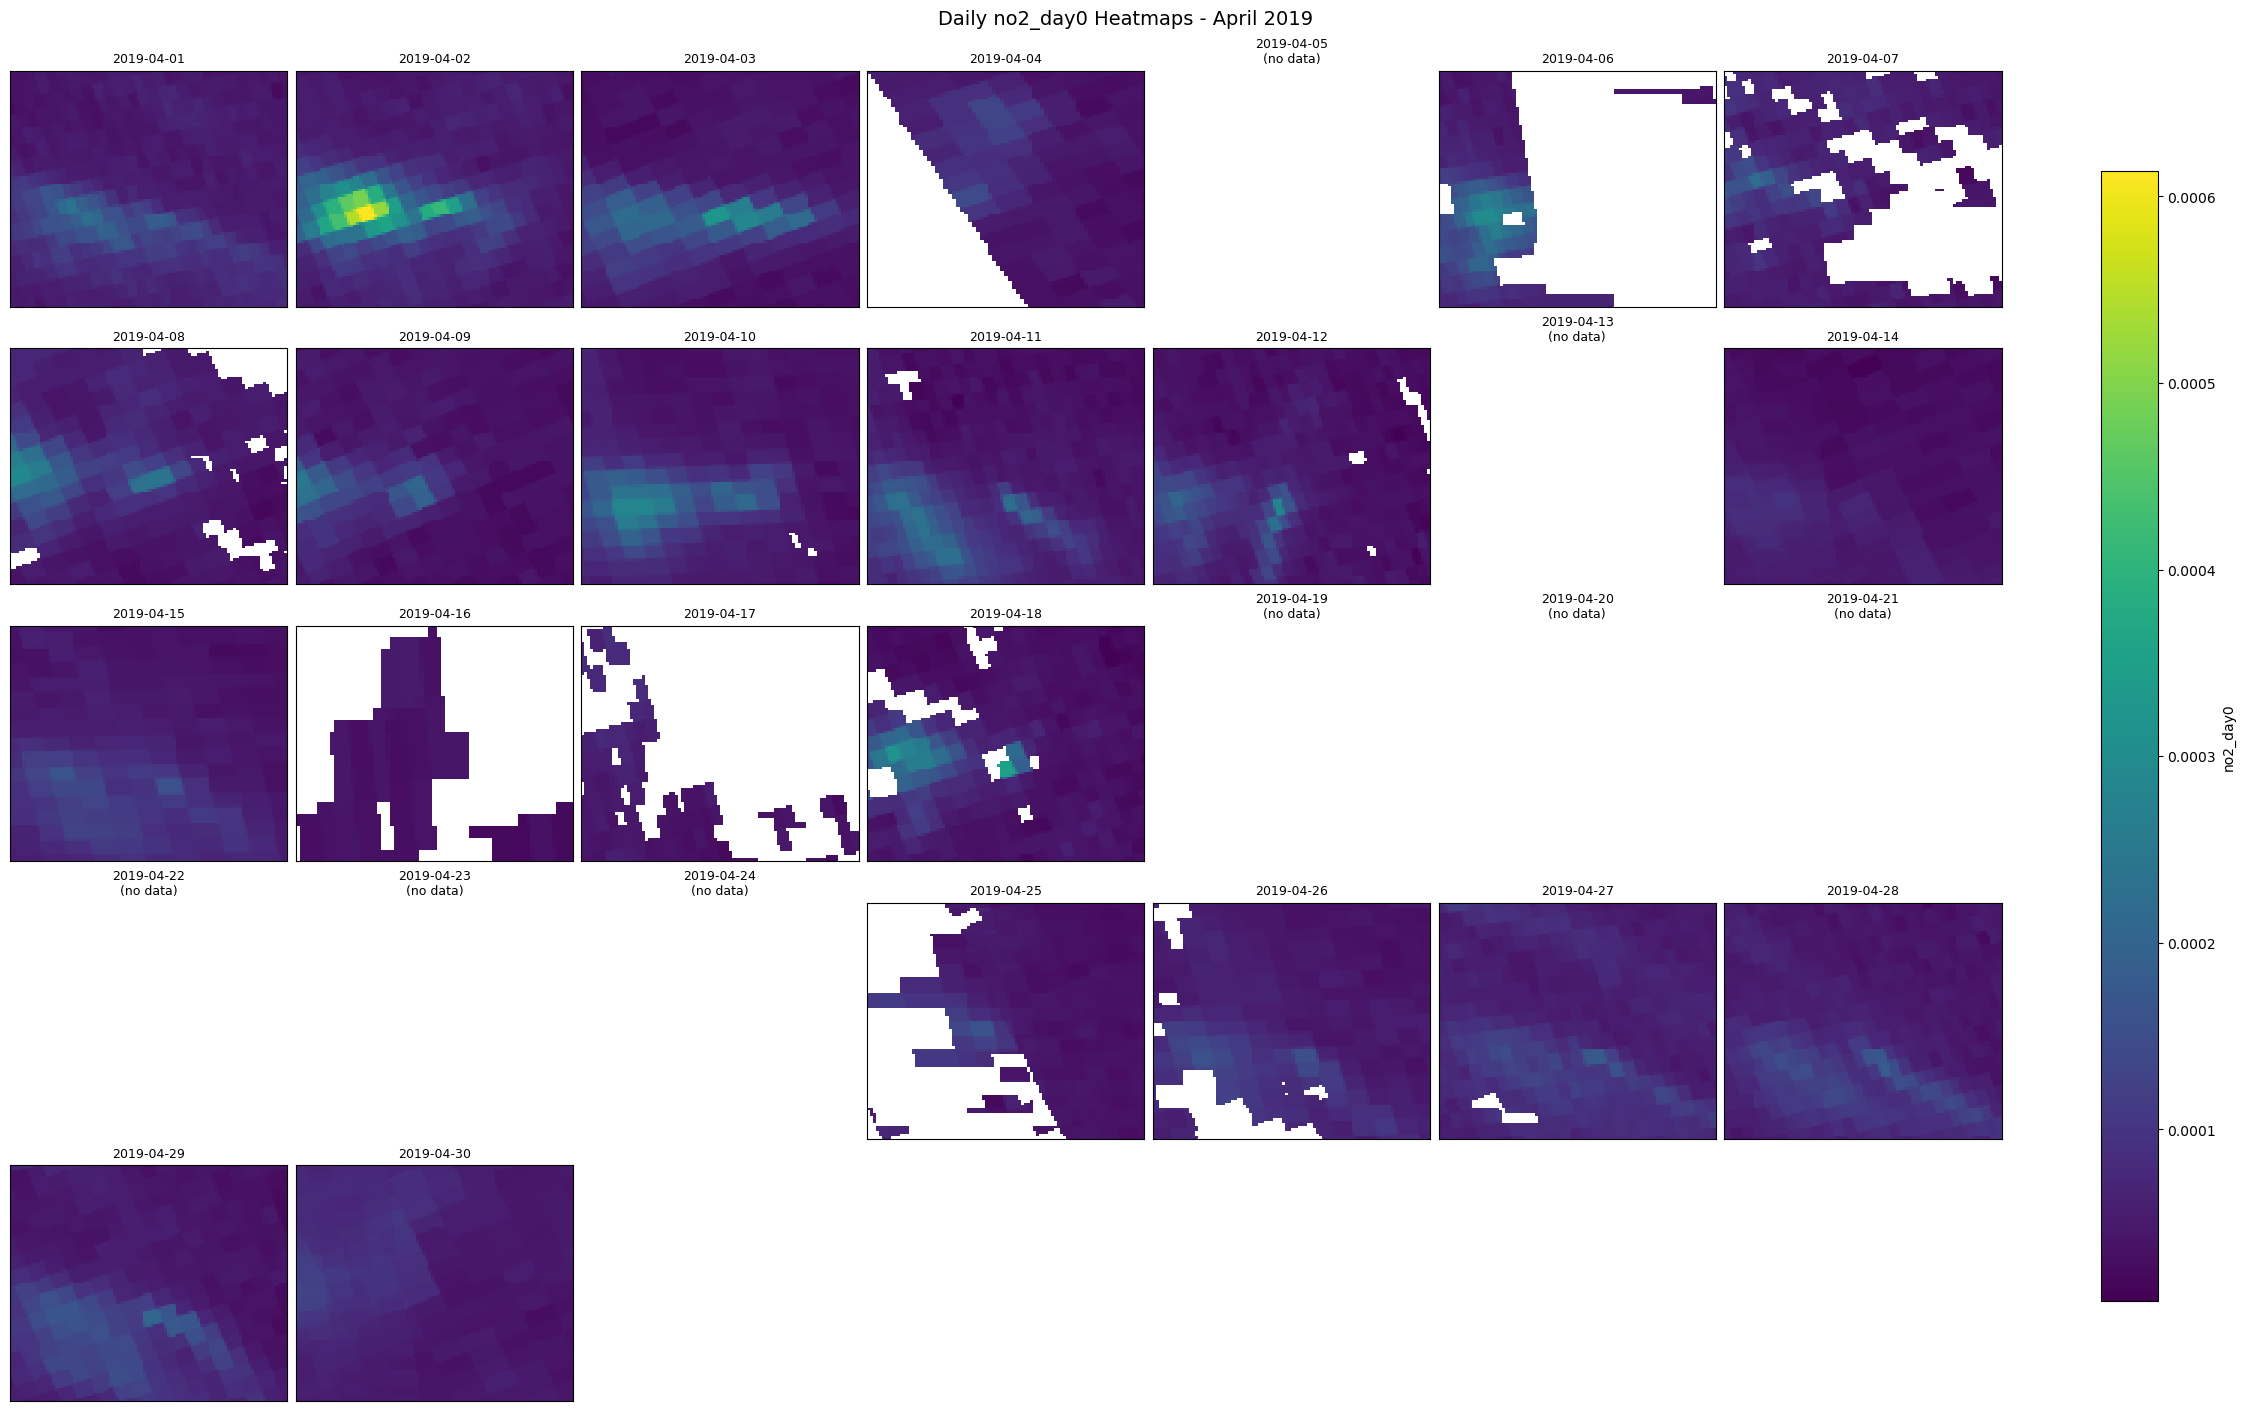

In [35]:
monthly_heatmaps(no2_lagged_df=no2_lagged_df, plot_col="no2_day0", selected_datetime=pd.to_datetime("2019-04-01"))

Checklist for next steps:
* ~~Build daily 2D grids from the tuples~~
* ~~Use last 7 days to predict next day~~
* Try:
    - ~~persistence baseline~~
    - ~~XGBoost on lagged features~~
    - Deep learning models:
        - CNN 
        - ConvLSTM 
        - Unet encoder-decoder
        - 3D CNN
* ~~Add mask + time features~~
* graph models if needed

# persistence baseline 

Persistence baseline for NO2
Train rows: 11,154,234
Test rows:  2,704,126
Time split:  2023-11-01 to 2024-12-31
MAE:  0.0000
RMSE: 0.0001
R^2:  0.0240
NMAE: 0.4139


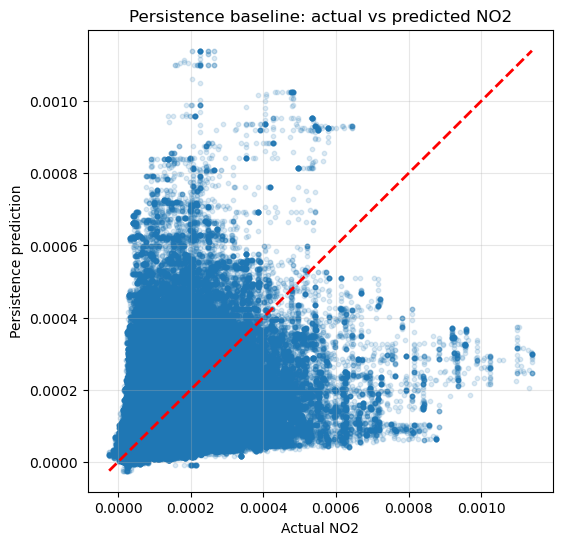

In [38]:
# Persistence baseline for NO2
# Idea: for each pixel-day, predict today's NO2 using yesterday's NO2.
# This is a strong sanity-check baseline before trying any neural network.

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1) Choose the target and the persistence feature.
# In this lagged table:
# - no2_day0 = today's NO2 (the thing we want to predict)
# - no2_day1 = yesterday's NO2 (the persistence forecast)
target_col = "no2_day0"
pred_col = "no2_day1"

# 2) Keep only rows where both target and persistence input exist.
baseline_df = no2_lagged_df[["timestamp", "latitude", "longitude", target_col, pred_col]].dropna().copy()
baseline_df = baseline_df.sort_values("timestamp").reset_index(drop=True)

# 3) Make a time-based split so we evaluate on future dates, not shuffled rows.
unique_dates = baseline_df["timestamp"].drop_duplicates().sort_values().to_list()
cutoff_index = max(1, int(len(unique_dates) * 0.8))
train_dates = set(unique_dates[:cutoff_index])
test_dates = set(unique_dates[cutoff_index:])

train_df = baseline_df[baseline_df["timestamp"].isin(train_dates)].copy()
test_df = baseline_df[baseline_df["timestamp"].isin(test_dates)].copy()

# 4) Evaluate the baseline on the held-out future period.
y_true = test_df[target_col].to_numpy()
y_pred = test_df[pred_col].to_numpy()

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

# A simple normalized error helps when NO2 values vary a lot across pixels.
mean_abs_target = np.mean(np.abs(y_true))
nmae = mae / mean_abs_target if mean_abs_target != 0 else np.nan

print("Persistence baseline for NO2")
print(f"Train rows: {len(train_df):,}")
print(f"Test rows:  {len(test_df):,}")
print(f"Time split:  {min(test_df['timestamp']).date()} to {max(test_df['timestamp']).date()}")
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R^2:  {r2:.4f}")
print(f"NMAE: {nmae:.4f}")

# # 5) Save predictions so you can inspect where persistence works well or fails.
# baseline_predictions = test_df[["timestamp", "latitude", "longitude", target_col, pred_col]].rename(
#     columns={target_col: "no2_true", pred_col: "no2_persistence_pred"}
# )

# 6) Quick diagnostic plot: actual vs predicted.
plt.figure(figsize=(6, 6))
plt.scatter(y_true, y_pred, alpha=0.15, s=10)
min_val = min(np.min(y_true), np.min(y_pred))
max_val = max(np.max(y_true), np.max(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], "r--", linewidth=2)
plt.xlabel("Actual NO2")
plt.ylabel("Persistence prediction")
plt.title("Persistence baseline: actual vs predicted NO2")
plt.grid(True, alpha=0.3)
plt.show()

# baseline_predictions.head()

# XGBoost 

We will use latitude, longitude, elevation, temperature, and the seven lagged NO2 values as features to predict `no2_day0`. The `datetime` column is only used to keep the train/test split chronological.

In [4]:
import pandas as pd
no2_lagged_df = pd.read_csv("./data/no2_lagged.csv")

In [11]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [ ]:
# Step 1: prepare the lagged dataframe for modeling
no2_lagged_df = no2_lagged_df.copy()
no2_lagged_df["timestamp"] = pd.to_datetime(no2_lagged_df["timestamp"])
no2_lagged_df = no2_lagged_df.sort_values(["timestamp", "latitude", "longitude"]).reset_index(drop=True)

# Step 2: define the features and the target
feature_cols = ["latitude", "longitude", "elevation", "TEMP"] + [f"no2_day{i}" for i in range(1,8)]
target_col = "no2_day0"

X = no2_lagged_df[feature_cols]
y = no2_lagged_df[target_col]

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")
print("Features used:", feature_cols)

# Step 3: split chronologically to avoid leaking future information into training
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False,
)

print(f"Train rows: {len(X_train):,}")
print(f"Test rows: {len(X_test):,}")

# Step 4: train an XGBoost regressor
xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.6,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    eval_metric="rmse",
    random_state=32746,
    n_jobs=-1,
    tree_method="exact",
)


In [10]:
eval_set = [(X_train, y_train), (X_test, y_test)]
xgb_model.fit(X_train, y_train, eval_set=eval_set, verbose=False)

# 2. Extract and Plot
results = xgb_model.evals_result()
epochs = len(results['validation_0']['rmse'])
x_axis = range(0, epochs)


NameError: name 'plt' is not defined

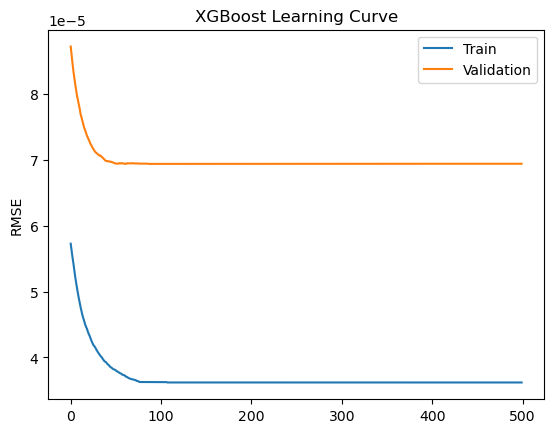

In [14]:
plt.plot(x_axis, results['validation_0']['rmse'], label='Train')
plt.plot(x_axis, results['validation_1']['rmse'], label='Validation')
plt.legend()
plt.ylabel('RMSE')
plt.title('XGBoost Learning Curve')
plt.show()

In [18]:
len(results["validation_0"]["rmse"])

500

In [28]:
y_pred = xgb_model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.6f}")
print(f"RMSE: {rmse:.6f}")
print(f"R^2: {r2:.4f}")

# Step 6: inspect which features the model relied on most
importance_df = pd.DataFrame(
    {
        "feature": feature_cols,
        "importance": xgb_model.feature_importances_,
    }
).sort_values("importance", ascending=False)

importance_df

MAE: 0.000035
RMSE: 0.000000
R^2: 0.3408


,feature,importance
4,no2_day1,0.403953
8,no2_day5,0.098219
5,no2_day2,0.089851
0,latitude,0.060094
3,TEMP,0.059577
6,no2_day3,0.057747
7,no2_day4,0.051686
9,no2_day6,0.051599
1,longitude,0.049940
10,no2_day7,0.043446


# Deep Learning:

Now we try the following architectures:
- [X] CNN 
- [X] ConvLSTM 
- [X] Unet encoder-decoder
- [] 3D CNN

# Data Regularisation and Masking for CNNs
We try to make a simple CNN architecture that takes in a radius-interpolated 2D grid of NO2 values and predicts the next day's NO2 values. We will stack the last 7 days of NO2 values as input channels to the CNN.

The problem here is that the satellite data is not on a regular grid, and it has many missing values. Instead of nearest-neighbor filling, we use radius-based inverse-distance weighting on a regular grid whose radius depends on the chosen grid size. Cells without local support stay masked, which keeps the missingness explicit for the CNN.
First, we identify the grid size we want to test, build a regular latitude/longitude lattice for each day, and interpolate the NO2 values within a radius tied to that grid spacing.

In [4]:

no2 = pd.read_csv("./data/NO2_manual_1213m.csv")

In [31]:
coords = no2[["latitude", "longitude"]].dropna().drop_duplicates().sort_values(["latitude", "longitude"])
lat_vals = np.sort(coords["latitude"].unique())
lon_vals = np.sort(coords["longitude"].unique())
lat_diffs = pd.Series(lat_vals).diff().dropna()
lon_diffs = pd.Series(lon_vals).diff().dropna()

print(f"Unique NO2 coordinates: {len(coords):,}")
print(f"Unique latitude values: {len(lat_vals):,}")
print(f"Unique longitude values: {len(lon_vals):,}")
print(f"Dense grid size from unique lat/lon axes: {len(lat_vals):,} x {len(lon_vals):,} = {len(lat_vals) * len(lon_vals):,} cells")
print(f"Latitude range: {lat_vals.min():.6f} to {lat_vals.max():.6f}")
print(f"Longitude range: {lon_vals.min():.6f} to {lon_vals.max():.6f}")
print(f"Typical latitude spacing: {lat_diffs.mode().iloc[0]:.6f}")
print(f"Typical longitude spacing: {lon_diffs.mode().iloc[0]:.6f}")

# Build a regular grid using the unique axis values.
# This preserves the dataset's native spatial resolution instead of inventing a new one.
no2_grid_shape = (len(lat_vals), len(lon_vals))
print(f"Recommended CNN grid shape for this dataset: {no2_grid_shape[0]} rows x {no2_grid_shape[1]} columns")

Unique NO2 coordinates: 64,579
Unique latitude values: 276
Unique longitude values: 551
Dense grid size from unique lat/lon axes: 276 x 551 = 152,076 cells
Latitude range: 28.197678 to 29.194199
Longitude range: 77.151198 to 78.147961
Typical latitude spacing: 0.006124
Typical longitude spacing: 0.001591
Recommended CNN grid shape for this dataset: 276 rows x 551 columns


In [6]:
from scipy.spatial import cKDTree

lat_vals = np.sort(no2["latitude"].dropna().unique())
lon_vals = np.sort(no2["longitude"].dropna().unique())

print(f"Regular grid from all NO2 coordinates: {len(lat_vals)} x {len(lon_vals)}")
print(f"Occupancy in the full lat/lon rectangle: {no2[['latitude', 'longitude']].dropna().drop_duplicates().shape[0] / (len(lat_vals) * len(lon_vals)):.3%}")


def _grid_axes_for_shape(source_df, grid_shape=None):
    if grid_shape is None:
        return lat_vals, lon_vals

    lat_axis = np.linspace(source_df["latitude"].min(), source_df["latitude"].max(), grid_shape[0])
    lon_axis = np.linspace(source_df["longitude"].min(), source_df["longitude"].max(), grid_shape[1])
    return lat_axis, lon_axis


def _radius_for_axes(lat_axis, lon_axis, radius_multiplier=1.5):
    if len(lat_axis) < 2 or len(lon_axis) < 2:
        return 0.0

    lat_step = float(np.median(np.diff(lat_axis)))
    lon_step = float(np.median(np.diff(lon_axis)))
    return radius_multiplier * float(np.hypot(lat_step, lon_step))


def build_radius_regular_grid(day_frame, grid_shape=None, value_col="NO2", radius_multiplier=1.5, power=2.0):
    """Convert scattered lat/lon observations into a regular grid using radius-based IDW."""
    lat_axis, lon_axis = _grid_axes_for_shape(no2, grid_shape)
    grid = np.full((len(lat_axis), len(lon_axis)), np.nan, dtype=np.float32)
    mask = np.zeros((len(lat_axis), len(lon_axis)), dtype=np.uint8)

    clean_frame = day_frame.dropna(subset=["latitude", "longitude", value_col]).copy()
    if clean_frame.empty:
        return grid, mask, lat_axis, lon_axis, 0.0

    points = clean_frame[["latitude", "longitude"]].to_numpy()
    values = clean_frame[value_col].to_numpy(dtype=np.float64)
    radius = _radius_for_axes(lat_axis, lon_axis, radius_multiplier=radius_multiplier)
    grid_lat, grid_lon = np.meshgrid(lat_axis, lon_axis, indexing="ij")
    target_points = np.column_stack([grid_lat.ravel(), grid_lon.ravel()])
    tree = cKDTree(points)
    neighbor_lists = tree.query_ball_point(target_points, r=radius)

    grid_flat = grid.ravel()
    mask_flat = mask.ravel()
    for cell_index, neighbor_indices in enumerate(neighbor_lists):
        if len(neighbor_indices) == 0:
            continue

        local_points = points[neighbor_indices]
        local_values = values[neighbor_indices]
        distances = np.linalg.norm(local_points - target_points[cell_index], axis=1)

        zero_distance = distances == 0
        if np.any(zero_distance):
            grid_flat[cell_index] = float(local_values[zero_distance][0])
            mask_flat[cell_index] = 1
            continue

        weights = 1.0 / np.power(np.maximum(distances, 1e-12), power)
        grid_flat[cell_index] = float(np.sum(weights * local_values) / np.sum(weights))
        mask_flat[cell_index] = 1

    return grid, mask, lat_axis, lon_axis, radius


no2_with_day = no2.copy()
no2_with_day["day"] = pd.to_datetime(no2_with_day["timestamp"], errors="coerce").dt.normalize()
example_day = no2_with_day[no2_with_day["day"] == no2_with_day["day"].min()].copy()
example_grid, example_mask, _, _, example_radius = build_radius_regular_grid(example_day, grid_shape=None, value_col="NO2")
print(f"Example daily grid shape: {example_grid.shape}")
print(f"Example radius used: {example_radius:.6f}")
print(f"Example grid coverage: {example_mask.mean():.3%}")

Regular grid from all NO2 coordinates: 276 x 734
Occupancy in the full lat/lon rectangle: 44.965%
Example daily grid shape: (276, 734)
Example radius used: 0.005338
Example grid coverage: 83.243%


In [7]:
from scipy.interpolate import RegularGridInterpolator

def evaluate_coarse_grid_accuracy(no2_df, grid_shape=(200,200), n_days=8, test_frac=0.2, random_state=42, radius_multiplier=1.5):
    """Measure how much error is introduced when you compress the raw points onto a smaller grid using radius-based interpolation."""
    work_df = no2_df[["timestamp", "latitude", "longitude", "NO2"]].dropna().copy()
    work_df["day"] = pd.to_datetime(work_df["timestamp"], errors="coerce").dt.normalize()
    work_df = work_df.dropna(subset=["day"])

    days = np.array(sorted(work_df["day"].drop_duplicates().to_list()))
    rng = np.random.default_rng(random_state)
    chosen_days = days if len(days) <= n_days else rng.choice(days, size=n_days, replace=False)
    chosen_days = pd.to_datetime(sorted(chosen_days))

    daily_rows = []
    for day in chosen_days:
        day_df = work_df.loc[work_df["day"] == day, ["latitude", "longitude", "NO2"]].dropna().copy()
        if len(day_df) < 20:
            continue

        perm = rng.permutation(len(day_df))
        split = max(1, int(len(day_df) * (1 - test_frac)))
        train_df = day_df.iloc[perm[:split]]
        test_df = day_df.iloc[perm[split:]]
        if len(test_df) == 0:
            continue

        train_points = train_df[["latitude", "longitude"]].to_numpy()
        train_values = train_df["NO2"].to_numpy()
        test_points = test_df[["latitude", "longitude"]].to_numpy()
        test_values = test_df["NO2"].to_numpy()

        train_frame = train_df[["latitude", "longitude", "NO2"]].copy()
        coarse_grid, coarse_mask, coarse_lat, coarse_lon, radius = build_radius_regular_grid(
            train_frame,
            grid_shape=grid_shape,
            value_col="NO2",
            radius_multiplier=radius_multiplier,
        )

        interpolator = RegularGridInterpolator((coarse_lat, coarse_lon), coarse_grid, bounds_error=False, fill_value=np.nan)
        predictions = interpolator(test_points)
        valid = ~np.isnan(predictions)
        if valid.sum() == 0:
            continue

        y_true = test_values[valid]
        y_pred = predictions[valid]
        mae = np.mean(np.abs(y_true - y_pred))
        rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
        ss_res = np.sum((y_true - y_pred) ** 2)
        ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
        r2 = 1 - (ss_res / ss_tot) if ss_tot != 0 else np.nan
        daily_rows.append({
            "day": day.date(),
            "grid_rows": grid_shape[0],
            "grid_cols": grid_shape[1],
            "radius": radius,
            "train_points": len(train_df),
            "test_points": len(test_df),
            "eval_points": int(valid.sum()),
            "mae": mae,
            "rmse": rmse,
            "r2": r2,
        })

    results = pd.DataFrame(daily_rows)
    if results.empty:
        raise ValueError("No days had enough points to evaluate the chosen grid size.")

    summary = {
        "grid_shape": grid_shape,
        "radius_multiplier": radius_multiplier,
        "days_evaluated": len(results),
        "mean_mae": results["mae"].mean(),
        "mean_rmse": results["rmse"].mean(),
        "median_mae": results["mae"].median(),
        "median_rmse": results["rmse"].median(),
    }
    return results, summary


chosen_grid_shape = (200,200)
daily_scores, score_summary = evaluate_coarse_grid_accuracy(no2, grid_shape=chosen_grid_shape, n_days=8, test_frac=0.2, radius_multiplier=1.5)

print(f"Chosen grid shape: {score_summary['grid_shape'][0]} x {score_summary['grid_shape'][1]}")
print(f"Radius multiplier: {score_summary['radius_multiplier']}")
print(f"Days evaluated: {score_summary['days_evaluated']}")
print(f"Mean MAE:  {score_summary['mean_mae']:.4f}")
print(f"Mean RMSE: {score_summary['mean_rmse']:.4f}")
print(f"Median MAE:  {score_summary['median_mae']:.4f}")
print(f"Median RMSE: {score_summary['median_rmse']:.4f}")

daily_scores.sort_values("mae")

Chosen grid shape: 200 x 200
Radius multiplier: 1.5
Days evaluated: 8
Mean MAE:  0.0000
Mean RMSE: 0.0000
Median MAE:  0.0000
Median RMSE: 0.0000


,day,grid_rows,grid_cols,radius,train_points,test_points,eval_points,mae,rmse,r2
1,2019-07-09,200,200,0.010633,17,5,2,6.776264e-21,6.776264e-21,NaN
2,2021-08-02,200,200,0.010633,472,118,67,1.361616e-06,3.276193e-06,0.920185
6,2023-08-27,200,200,0.010633,6305,1577,1139,1.375083e-06,2.979661e-06,0.962756
7,2024-03-01,200,200,0.010633,3775,944,675,2.408587e-06,5.022556e-06,0.966635
3,2021-08-15,200,200,0.010633,8535,2134,1820,3.637860e-06,5.597272e-06,0.691640
5,2023-03-11,200,200,0.010633,6771,1693,1219,3.872173e-06,8.063834e-06,0.985344
0,2019-07-03,200,200,0.010633,8065,2017,1716,5.874074e-06,9.697124e-06,0.565497
4,2022-12-05,200,200,0.010633,6771,1693,1268,6.121403e-06,1.139248e-05,0.987696


In [8]:
# Compare several smaller grid sizes on the same evaluation setup.
candidate_grid_shapes = [(48, 48), (64, 64), (100,100), (128, 128), (200,200)]
comparison_rows = []

for grid_shape in candidate_grid_shapes:
    scores, summary = evaluate_coarse_grid_accuracy(
        no2,
        grid_shape=grid_shape,
        n_days=8,
        test_frac=0.2,
        random_state=42,
        radius_multiplier=1.5,
    )
    comparison_rows.append({
        "grid_rows": grid_shape[0],
        "grid_cols": grid_shape[1],
        "cells": grid_shape[0] * grid_shape[1],
        "days_evaluated": summary["days_evaluated"],
        "radius_multiplier": summary["radius_multiplier"],
        "mean_mae": summary["mean_mae"],
        "mean_rmse": summary["mean_rmse"],
        "median_mae": summary["median_mae"],
        "median_rmse": summary["median_rmse"],
    })

grid_comparison_df = pd.DataFrame(comparison_rows).sort_values(["mean_rmse", "cells"]).reset_index(drop=True)
grid_comparison_df["compression_vs_full"] = grid_comparison_df["cells"] / (len(lat_vals) * len(lon_vals))
grid_comparison_df

,grid_rows,grid_cols,cells,days_evaluated,radius_multiplier,mean_mae,mean_rmse,median_mae,median_rmse,compression_vs_full
0,128,128,16384,8,1.5,0.000003,0.000005,0.000003,0.000005,0.080875
1,100,100,10000,8,1.5,0.000003,0.000005,0.000003,0.000005,0.049362
2,200,200,40000,8,1.5,0.000003,0.000006,0.000003,0.000005,0.197449
3,64,64,4096,8,1.5,0.000004,0.000006,0.000003,0.000005,0.020219
4,48,48,2304,8,1.5,0.000004,0.000006,0.000004,0.000005,0.011373


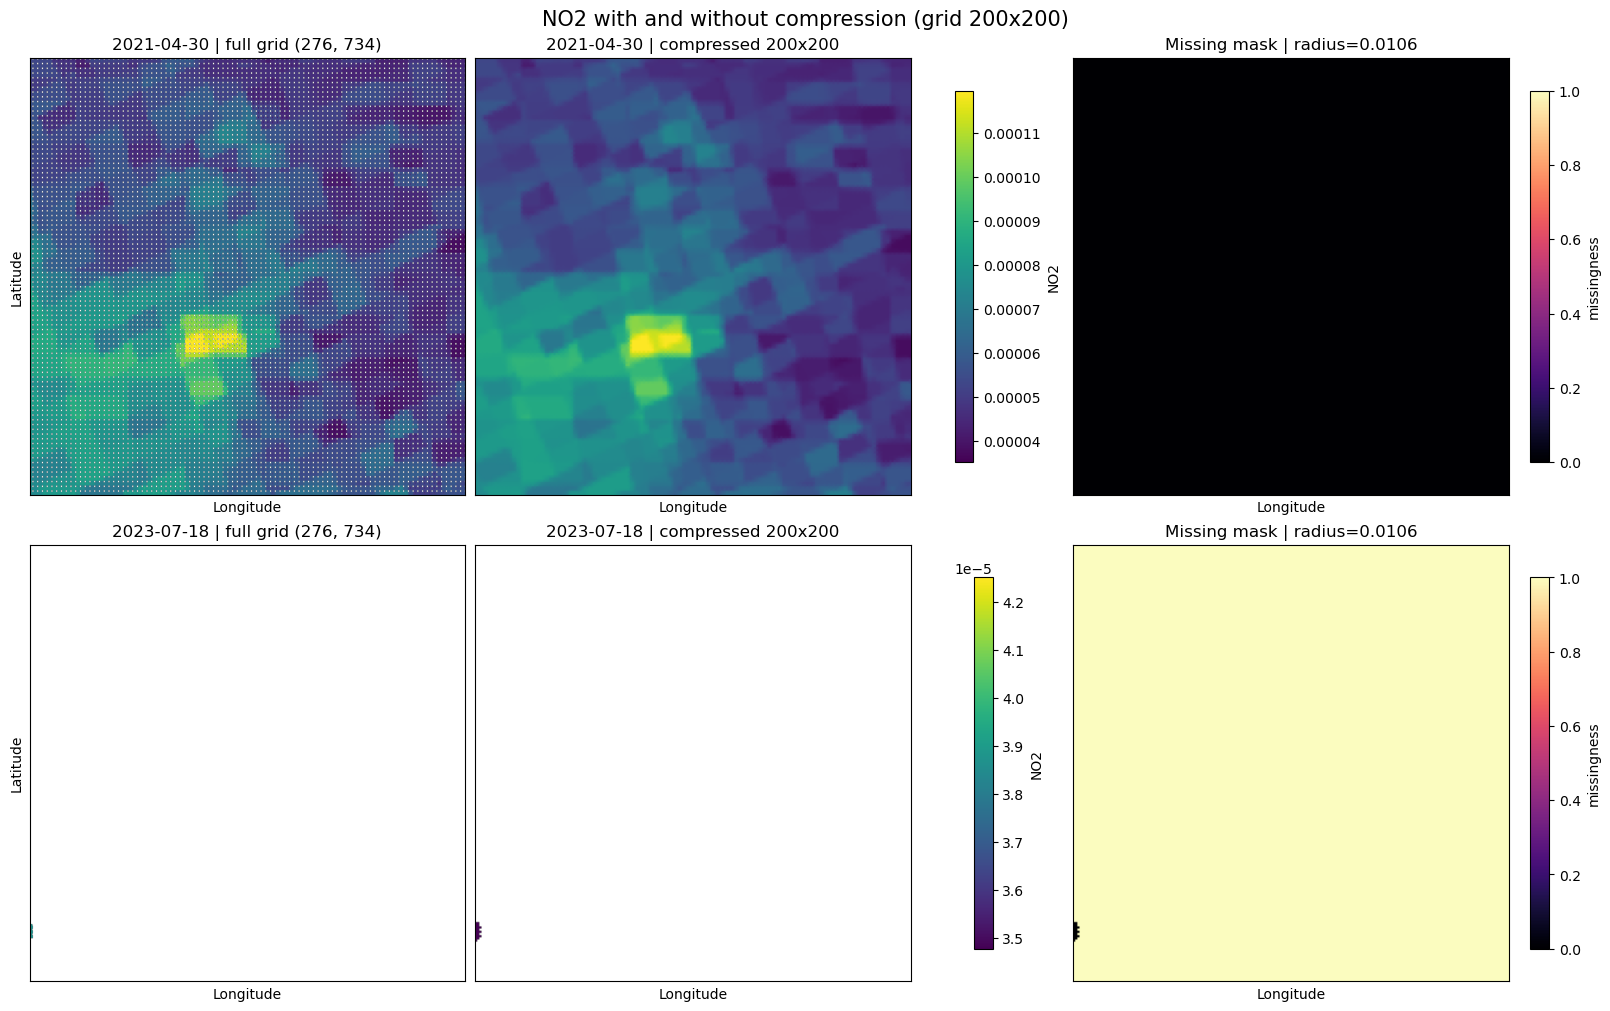

In [9]:
def plot_compression_examples(no2_df, grid_shape=(200,200), n_days=2, value_col="NO2", radius_multiplier=1.5):
    """Plot the same day with and without spatial compression using radius-based interpolation."""
    work_df = no2_df[["timestamp", "latitude", "longitude", value_col]].dropna().copy()
    work_df["day"] = pd.to_datetime(work_df["timestamp"], errors="coerce").dt.normalize()
    work_df = work_df.dropna(subset=["day"])

    day_counts = work_df.groupby("day").size().sort_values(ascending=False)
    if day_counts.empty:
        raise ValueError("No valid days found for plotting.")

    if n_days <= 1:
        sample_days = pd.to_datetime([day_counts.index[0]])
    elif n_days == 2:
        sample_days = pd.to_datetime([day_counts.index[0], day_counts.index[-1]])
    else:
        sample_days = pd.to_datetime(day_counts.iloc[np.linspace(0, len(day_counts) - 1, n_days, dtype=int)].index.sort_values())
    full_extent = [lon_vals.min(), lon_vals.max(), lat_vals.min(), lat_vals.max()]

    fig, axes = plt.subplots(len(sample_days), 3, figsize=(16, 5 * len(sample_days)), constrained_layout=True)
    if len(sample_days) == 1:
        axes = np.array([axes])

    for row_idx, day in enumerate(sample_days):
        day_df = work_df.loc[work_df["day"] == day, ["latitude", "longitude", value_col]].dropna().copy()
        if day_df.empty:
            continue

        full_grid, full_mask, full_lat_axis, full_lon_axis, full_radius = build_radius_regular_grid(day_df, grid_shape=None, value_col=value_col, radius_multiplier=radius_multiplier)
        compressed_grid, compressed_mask, compressed_lat_axis, compressed_lon_axis, compressed_radius = build_radius_regular_grid(day_df, grid_shape=grid_shape, value_col=value_col, radius_multiplier=radius_multiplier)

        shared_vmin = np.nanmin([np.nanmin(full_grid), np.nanmin(compressed_grid)])
        shared_vmax = np.nanmax([np.nanmax(full_grid), np.nanmax(compressed_grid)])

        ax0, ax1, ax2 = axes[row_idx]
        im0 = ax0.imshow(full_grid, origin="lower", aspect="auto", cmap="viridis", vmin=shared_vmin, vmax=shared_vmax, extent=full_extent)
        ax0.set_title(f"{day.date()} | full grid {full_grid.shape}")
        ax0.set_xlabel("Longitude")
        ax0.set_ylabel("Latitude")

        compressed_extent = [compressed_lon_axis.min(), compressed_lon_axis.max(), compressed_lat_axis.min(), compressed_lat_axis.max()]
        im1 = ax1.imshow(compressed_grid, origin="lower", aspect="auto", cmap="viridis", vmin=shared_vmin, vmax=shared_vmax, extent=compressed_extent)
        ax1.set_title(f"{day.date()} | compressed {grid_shape[0]}x{grid_shape[1]}")
        ax1.set_xlabel("Longitude")

        missing_mask = 1 - compressed_mask
        im2 = ax2.imshow(missing_mask, origin="lower", aspect="auto", cmap="magma", vmin=0, vmax=1, extent=compressed_extent)
        ax2.set_title(f"Missing mask | radius={compressed_radius:.4f}")
        ax2.set_xlabel("Longitude")

        for ax in (ax0, ax1, ax2):
            ax.set_yticks([])
            ax.set_xticks([])

        fig.colorbar(im0, ax=[ax0, ax1], shrink=0.85, label=value_col)
        fig.colorbar(im2, ax=ax2, shrink=0.85, label="missingness")

    fig.suptitle(f"NO2 with and without compression (grid {grid_shape[0]}x{grid_shape[1]})", fontsize=15)
    plt.show()


plot_compression_examples(no2, grid_shape=(200,200), n_days=2, value_col="NO2", radius_multiplier=1.5)

In [10]:
def create_regularized_no2_dataset(no2_df, grid_shape=(200,200), value_col="NO2", min_points=20, radius_multiplier=1.5):
    """Create one compressed regular-grid NO2 frame per day using radius-based interpolation."""
    work_df = no2_df[["timestamp", "latitude", "longitude", value_col]].dropna().copy()
    work_df["day"] = pd.to_datetime(work_df["timestamp"], errors="coerce").dt.normalize()
    work_df = work_df.dropna(subset=["day"])

    if work_df.empty:
        raise ValueError("no2_df has no valid timestamp/latitude/longitude/value rows.")

    records = []
    grid_stack = []
    mask_stack = []
    day_groups = work_df.groupby("day", sort=True)

    for day, day_df in day_groups:
        if len(day_df) < min_points:
            continue

        compressed_grid, compressed_mask, lat_axis, lon_axis, radius = build_radius_regular_grid(
            day_df,
            grid_shape=grid_shape,
            value_col=value_col,
            radius_multiplier=radius_multiplier,
        )

        grid_stack.append(compressed_grid.astype(np.float32))
        mask_stack.append(compressed_mask.astype(np.uint8))
        records.append({
            "datetime": day,
            "n_observations": len(day_df),
            "grid": compressed_grid.astype(np.float32),
            "mask": compressed_mask.astype(np.uint8),
            "coverage_fraction": float(compressed_mask.mean()),
        })

    if not records:
        raise ValueError("No days had enough points to build a compressed dataset.")

    regularized_df = pd.DataFrame(records)
    grid_tensor = np.stack(grid_stack, axis=0)
    mask_tensor = np.stack(mask_stack, axis=0)

    return regularized_df, grid_tensor, mask_tensor, lat_axis, lon_axis


chosen_grid_shape = (200,200)
regularized_no2_df, regularized_no2_tensor, regularized_no2_mask_tensor, compressed_lat_axis, compressed_lon_axis = create_regularized_no2_dataset(
    no2,
    grid_shape=chosen_grid_shape,
    value_col="NO2",
    min_points=20,
    radius_multiplier=1.5,
)

print(f"Created compressed NO2 dataset with {len(regularized_no2_df):,} days.")
print(f"Grid tensor shape: {regularized_no2_tensor.shape}  (days, rows, cols)")
print(f"Mask tensor shape: {regularized_no2_mask_tensor.shape}")
print(f"Latitude axis length: {len(compressed_lat_axis)}")
print(f"Longitude axis length: {len(compressed_lon_axis)}")
print(regularized_no2_df[["datetime", "n_observations", "coverage_fraction"]].head())

np.savez_compressed(
    "./data/no2_regularized_200x200.npz",
    datetime=regularized_no2_df["datetime"].dt.strftime("%Y-%m-%d").to_numpy(),
    n_observations=regularized_no2_df["n_observations"].to_numpy(),
    coverage_fraction=regularized_no2_df["coverage_fraction"].to_numpy(),
    grids=regularized_no2_tensor,
    masks=regularized_no2_mask_tensor,
    lat_axis=compressed_lat_axis,
    lon_axis=compressed_lon_axis,
    grid_shape=np.array(chosen_grid_shape, dtype=np.int32),
)

metadata_df = regularized_no2_df[["datetime", "n_observations", "coverage_fraction"]].copy()
metadata_df["lat_axis"] = None
metadata_df["lon_axis"] = None
metadata_df["lat_axis"][0] = [compressed_lat_axis.tolist()] * len(metadata_df)
metadata_df["lon_axis"][0] = [compressed_lon_axis.tolist()] * len(metadata_df)
metadata_df.to_csv("./data/no2_regularized_200x200_metadata.csv", index=False)

regularized_no2_df.head()


Created compressed NO2 dataset with 2,047 days.
Grid tensor shape: (2047, 200, 200)  (days, rows, cols)
Mask tensor shape: (2047, 200, 200)
Latitude axis length: 200
Longitude axis length: 200
    datetime  n_observations  coverage_fraction
0 2019-01-01            8464           1.000000
1 2019-01-02            4479           0.544800
2 2019-01-03           13007           0.964625
3 2019-01-05            8464           1.000000
4 2019-01-06            4452           0.548625


/tmp/ipykernel_5769/3025303723.py:77: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  metadata_df["lat_axis"][0] = [compressed_lat_axis.tolist()] * len(metadata_df)
/tmp/ipykernel_5769/3025303723.py:77: SettingWithCopyWarning: 
A value is tryi

,datetime,n_observations,grid,mask,coverage_fraction
0,2019-01-01,8464,"[[0.000102101694, 9.498377e-05, 8.53256e-05, 8...","[[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,...",1.000000
1,2019-01-02,4479,"[[4.2139814e-05, 3.9765146e-05, 3.6543006e-05,...","[[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,...",0.544800
2,2019-01-03,13007,"[[5.6902794e-05, 5.9230402e-05, 6.238868e-05, ...","[[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,...",0.964625
3,2019-01-05,8464,"[[5.1588722e-05, 5.282253e-05, 5.449665e-05, 5...","[[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,...",1.000000
4,2019-01-06,4452,"[[nan, nan, nan, nan, nan, nan, nan, nan, nan,...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",0.548625


Now that the NO2 data is on a regular grid, we can model each day as a 2D image.
The basic setup is:

1. Stack the previous 7 days as input channels.
2. Keep the missing-value masks as extra channels.
3. Predict the next day's NO2 grid.
4. Compute loss only on cells where the target mask is valid.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from pathlib import Path


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

regularized_path = Path("./data/no2_regularized_200x200.npz")
if not regularized_path.exists():
    raise FileNotFoundError(f"Could not find {regularized_path}. Run the regularization cell first.")

with np.load(regularized_path, allow_pickle=True) as data:
    regularized_no2_tensor = data["grids"].astype(np.float32)
    regularized_no2_mask_tensor = data["masks"].astype(np.float32)
    regularized_dates = pd.to_datetime(data["datetime"])
    compressed_lat_axis = data["lat_axis"].astype(np.float32)
    compressed_lon_axis = data["lon_axis"].astype(np.float32)

print("Grid tensor shape:", regularized_no2_tensor.shape)
print("Mask tensor shape:", regularized_no2_mask_tensor.shape)
print("Date range:", regularized_dates.min(), "->", regularized_dates.max())
print("Latitude axis length:", len(compressed_lat_axis))
print("Longitude axis length:", len(compressed_lon_axis))


def masked_mean_std(grids, masks):
    observed_values = grids[masks > 0]
    if observed_values.size == 0:
        raise ValueError("No observed values found while computing normalization stats.")

    mean = float(observed_values.mean())
    std = float(observed_values.std())
    if std < 1e-6:
        std = 1.0
    return mean, std


def normalize_grid(grid, mean, std):
    normalized = (grid - mean) / std
    return np.nan_to_num(normalized, nan=0.0).astype(np.float32)


lookback = 7
num_days = len(regularized_no2_tensor)
if num_days <= lookback:
    raise ValueError(f"Need more than {lookback} daily grids to build temporal samples.")

train_fraction = 0.7
val_fraction = 0.15
train_end = max(lookback + 1, int(num_days * train_fraction))
val_end = max(train_end + 1, int(num_days * (train_fraction + val_fraction)))
val_end = min(val_end, num_days - 1)

train_mean, train_std = masked_mean_std(
    regularized_no2_tensor[:train_end],
    regularized_no2_mask_tensor[:train_end],
)
print(f"Training normalization mean: {train_mean:.4f}")
print(f"Training normalization std:  {train_std:.4f}")


class NO2TemporalGridDataset(Dataset):
    def __init__(self, grids, masks, dates, lookback, mean, std, target_indices):
        self.grids = grids
        self.masks = masks
        self.dates = pd.to_datetime(dates)
        self.lookback = lookback
        self.mean = mean
        self.std = std
        self.target_indices = np.asarray(target_indices, dtype=np.int64)

    def __len__(self):
        return len(self.target_indices)

    def __getitem__(self, item):
        target_idx = int(self.target_indices[item])
        input_grids = self.grids[target_idx - self.lookback:target_idx]
        input_masks = self.masks[target_idx - self.lookback:target_idx]
        target_grid = self.grids[target_idx]
        target_mask = self.masks[target_idx]

        input_grids = normalize_grid(input_grids, self.mean, self.std)
        target_grid = normalize_grid(target_grid, self.mean, self.std)

        x = np.concatenate([input_grids, input_masks], axis=0).astype(np.float32)
        y = target_grid[np.newaxis, ...].astype(np.float32)
        y_mask = target_mask[np.newaxis, ...].astype(np.float32)

        return torch.from_numpy(x), torch.from_numpy(y), torch.from_numpy(y_mask)


all_target_indices = np.arange(lookback, num_days)
train_target_indices = all_target_indices[all_target_indices < train_end]
val_target_indices = all_target_indices[(all_target_indices >= train_end) & (all_target_indices < val_end)]
test_target_indices = all_target_indices[all_target_indices >= val_end]

train_dataset = NO2TemporalGridDataset(
    regularized_no2_tensor,
    regularized_no2_mask_tensor,
    regularized_dates,
    lookback,
    train_mean,
    train_std,
    train_target_indices,
)
val_dataset = NO2TemporalGridDataset(
    regularized_no2_tensor,
    regularized_no2_mask_tensor,
    regularized_dates,
    lookback,
    train_mean,
    train_std,
    val_target_indices,
)
test_dataset = NO2TemporalGridDataset(
    regularized_no2_tensor,
    regularized_no2_mask_tensor,
    regularized_dates,
    lookback,
    train_mean,
    train_std,
    test_target_indices,
)

batch_size = 8
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

print(f"Train samples: {len(train_dataset):,}")
print(f"Validation samples: {len(val_dataset):,}")
print(f"Test samples: {len(test_dataset):,}")

Using device: cpu
Grid tensor shape: (338, 100, 100)
Mask tensor shape: (338, 100, 100)
Date range: 2019-01-01 00:00:00 -> 2019-12-31 00:00:00
Latitude axis length: 100
Longitude axis length: 100
Training normalization mean: 0.0001
Training normalization std:  0.0001
Train samples: 229
Validation samples: 51
Test samples: 51


# Mask-aware CNN on the regularized NO2 grids

Now that the data lives on a regular lattice, the next step is to treat each day like an image. The model will see two channels per historical day: standardized NO2 values and a binary mask that marks which cells were observed. The loss is masked as well, so only observed target cells contribute to training.

In [38]:
class MaskAwareCNN(nn.Module):
    def __init__(self, in_channels, hidden_channels=64):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels, hidden_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden_channels, hidden_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden_channels, hidden_channels // 2, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden_channels // 2),
            nn.ReLU(inplace=True),
        )
        self.head = nn.Conv2d(hidden_channels // 2, 1, kernel_size=1)

    def forward(self, x):
        features = self.encoder(x)
        return self.head(features)


def masked_mse(prediction, target, target_mask, eps=1e-6):
    squared_error = (prediction - target) ** 2 * target_mask
    return squared_error.sum() / target_mask.sum().clamp_min(eps)


model = MaskAwareCNN(in_channels=lookback * 2).to(device)
print(model)

MaskAwareCNN(
  (encoder): Sequential(
    (0): Conv2d(14, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): Conv2d(64, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
  )
  (head): Conv2d(32, 1, kernel_size=(1, 1), stride=(1, 1))
)


In [39]:
def run_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)

    total_loss = 0.0
    total_masked_mae = 0.0
    total_masked_points = 0.0

    for x, y, y_mask in loader:
        x = x.to(device)
        y = y.to(device)
        y_mask = y_mask.to(device)

        if is_train:
            optimizer.zero_grad(set_to_none=True)

        prediction = model(x)
        loss = masked_mse(prediction, y, y_mask)

        if is_train:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        with torch.no_grad():
            masked_abs_error = (prediction - y).abs() * y_mask
            batch_masked_points = y_mask.sum().item()
            total_loss += loss.item() * max(batch_masked_points, 1.0)
            total_masked_mae += masked_abs_error.sum().item()
            total_masked_points += batch_masked_points

    mean_loss = total_loss / max(total_masked_points, 1.0)
    mean_mae = total_masked_mae / max(total_masked_points, 1.0)
    return mean_loss, mean_mae


torch.manual_seed(42)
np.random.seed(42)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", patience=3, factor=0.5)

best_val_loss = float("inf")
best_state = None
history = []
num_epochs = 15

for epoch in range(1, num_epochs + 1):
    train_loss, train_mae = run_epoch(model, train_loader, optimizer=optimizer)
    val_loss, val_mae = run_epoch(model, val_loader)
    scheduler.step(val_loss)

    history.append(
        {
            "epoch": epoch,
            "train_loss": train_loss,
            "train_mae": train_mae,
            "val_loss": val_loss,
            "val_mae": val_mae,
        }
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}

    print(
        f"Epoch {epoch:02d} | "
        f"train loss {train_loss:.4f} | train mae {train_mae:.4f} | "
        f"val loss {val_loss:.4f} | val mae {val_mae:.4f}"
    )

if best_state is not None:
    model.load_state_dict(best_state)

history_df = pd.DataFrame(history)
history_df

Epoch 01 | train loss 0.7221 | train mae 0.4625 | val loss 0.2176 | val mae 0.2893
Epoch 02 | train loss 0.6125 | train mae 0.4357 | val loss 0.2040 | val mae 0.2803
Epoch 03 | train loss 0.5965 | train mae 0.4219 | val loss 0.1993 | val mae 0.2630


KeyboardInterrupt: 

Test MAE:  0.0000
Test RMSE: 0.0001


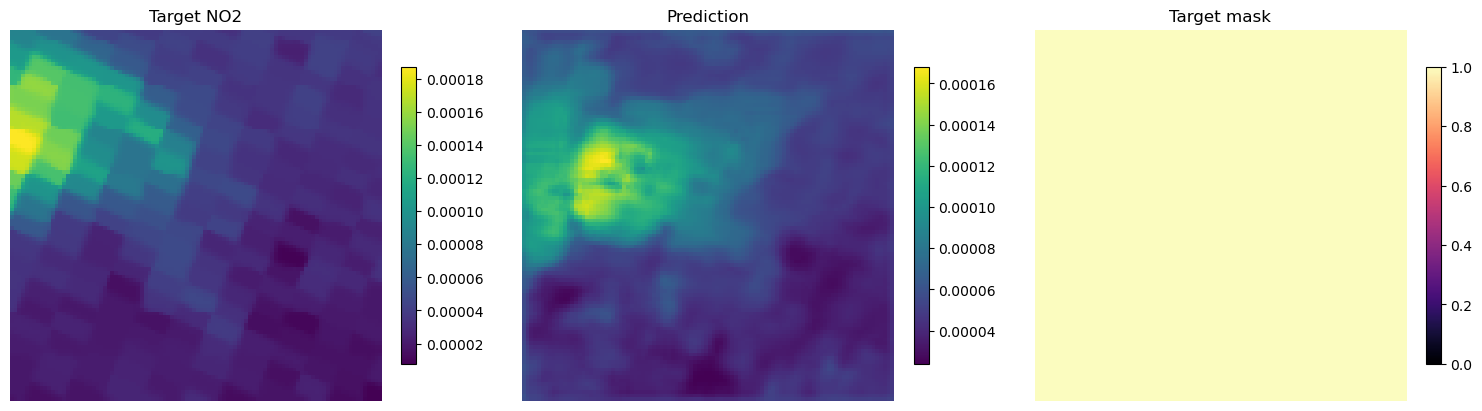

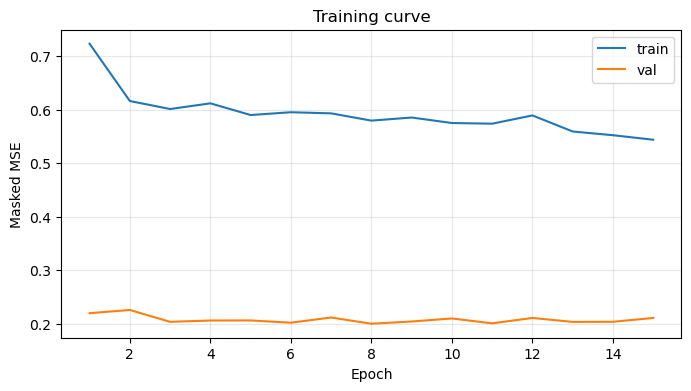

In [40]:
from random import randint
def evaluate_on_loader(model, loader, mean, std):
    model.eval()
    preds = []
    targets = []
    masks = []

    with torch.no_grad():
        for x, y, y_mask in loader:
            x = x.to(device)
            y = y.to(device)
            y_mask = y_mask.to(device)
            prediction = model(x)

            preds.append(prediction.cpu().numpy())
            targets.append(y.cpu().numpy())
            masks.append(y_mask.cpu().numpy())

    preds = np.concatenate(preds, axis=0)
    targets = np.concatenate(targets, axis=0)
    masks = np.concatenate(masks, axis=0)

    preds = preds * std + mean
    targets = targets * std + mean

    valid = masks > 0
    mae = np.mean(np.abs(preds[valid] - targets[valid]))
    rmse = np.sqrt(np.mean((preds[valid] - targets[valid]) ** 2))
    return preds, targets, masks, mae, rmse


preds, targets, masks, test_mae, test_rmse = evaluate_on_loader(model, test_loader, train_std, train_mean)
print(f"Test MAE:  {test_mae:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")

sample_index = randint(0, len(test_dataset))
sample_x, sample_y, sample_mask = test_dataset[sample_index]
with torch.no_grad():
    sample_pred = model(sample_x.unsqueeze(0).to(device)).cpu().squeeze(0).squeeze(0)

sample_target = sample_y.squeeze(0) * train_std + train_mean
sample_prediction = sample_pred * train_std + train_mean
sample_mask_2d = sample_mask.squeeze(0)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)

im0 = axes[0].imshow(sample_target.numpy(), cmap="viridis")
axes[0].set_title("Target NO2")
axes[0].axis("off")

im1 = axes[1].imshow(sample_prediction.numpy(), cmap="viridis")
axes[1].set_title("Prediction")
axes[1].axis("off")

im2 = axes[2].imshow(sample_mask_2d.numpy(), cmap="magma", vmin=0, vmax=1)
axes[2].set_title("Target mask")
axes[2].axis("off")

fig.colorbar(im0, ax=axes[0], shrink=0.8)
fig.colorbar(im1, ax=axes[1], shrink=0.8)
fig.colorbar(im2, ax=axes[2], shrink=0.8)
plt.show()

if not history_df.empty:
    plt.figure(figsize=(8, 4))
    plt.plot(history_df["epoch"], history_df["train_loss"], label="train")
    plt.plot(history_df["epoch"], history_df["val_loss"], label="val")
    plt.xlabel("Epoch")
    plt.ylabel("Masked MSE")
    plt.title("Training curve")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

# ConvLSTM
The ConvLSTM architecture is designed to capture spatiotemporal dependencies in data. ConvLSTM especially captures the temporal evolution of spatial patterns, which is crucial for our task of predicting NO2 levels based on historical data. 


In [43]:
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn


class NO2TemporalSequenceDataset(Dataset):
    def __init__(self, grids, masks, dates, lookback, mean, std, target_indices):
        self.grids = grids
        self.masks = masks
        self.dates = dates
        self.lookback = lookback
        self.mean = mean
        self.std = std
        self.target_indices = target_indices

    def __len__(self):
        return len(self.target_indices)

    def __getitem__(self, idx):
        target_idx = self.target_indices[idx]
        start_idx = target_idx - self.lookback

        input_grids = np.nan_to_num(self.grids[start_idx:target_idx], nan=0.0).astype(np.float32)
        input_masks = np.nan_to_num(self.masks[start_idx:target_idx], nan=0.0).astype(np.float32)
        input_seq = np.stack([input_grids, input_masks], axis=1).astype(np.float32)

        if self.mean is not None and self.std is not None:
            input_seq[:, 0] = (input_seq[:, 0] - self.mean) / self.std

        target = np.nan_to_num(self.grids[target_idx][None, ...], nan=0.0).astype(np.float32)
        target_mask = np.nan_to_num(self.masks[target_idx][None, ...], nan=0.0).astype(np.float32)

        if self.mean is not None and self.std is not None:
            target = (target - self.mean) / self.std

        return (
            torch.from_numpy(input_seq),
            torch.from_numpy(target),
            torch.from_numpy(target_mask),
        )


convlstm_train_dataset = NO2TemporalSequenceDataset(
    regularized_no2_tensor,
    regularized_no2_mask_tensor,
    regularized_dates,
    lookback,
    train_mean,
    train_std,
    train_target_indices,
)
convlstm_val_dataset = NO2TemporalSequenceDataset(
    regularized_no2_tensor,
    regularized_no2_mask_tensor,
    regularized_dates,
    lookback,
    train_mean,
    train_std,
    val_target_indices,
)
convlstm_test_dataset = NO2TemporalSequenceDataset(
    regularized_no2_tensor,
    regularized_no2_mask_tensor,
    regularized_dates,
    lookback,
    train_mean,
    train_std,
    test_target_indices,
)

convlstm_train_loader = DataLoader(convlstm_train_dataset, batch_size=batch_size, shuffle=True)
convlstm_val_loader = DataLoader(convlstm_val_dataset, batch_size=batch_size, shuffle=False)
convlstm_test_loader = DataLoader(convlstm_test_dataset, batch_size=batch_size, shuffle=False)


class ConvLSTMCell(nn.Module):
    def __init__(self, input_dim, hidden_dim, kernel_size=3):
        super().__init__()
        padding = kernel_size // 2
        self.hidden_dim = hidden_dim
        self.gates = nn.Conv2d(input_dim + hidden_dim, 4 * hidden_dim, kernel_size, padding=padding)

    def forward(self, x, state):
        h_prev, c_prev = state
        combined = torch.cat([x, h_prev], dim=1)
        gates = self.gates(combined)
        input_gate, forget_gate, output_gate, candidate_gate = torch.chunk(gates, 4, dim=1)
        input_gate = torch.sigmoid(input_gate)
        forget_gate = torch.sigmoid(forget_gate)
        output_gate = torch.sigmoid(output_gate)
        candidate_gate = torch.tanh(candidate_gate)
        c_next = forget_gate * c_prev + input_gate * candidate_gate
        h_next = output_gate * torch.tanh(c_next)
        return h_next, c_next


class MaskAwareConvLSTM(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=32, kernel_size=3):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.cell = ConvLSTMCell(input_dim=input_dim, hidden_dim=hidden_dim, kernel_size=kernel_size)
        self.decoder = nn.Sequential(
            nn.Conv2d(hidden_dim, hidden_dim, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden_dim),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden_dim, hidden_dim // 2, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden_dim // 2),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden_dim // 2, 1, kernel_size=1),
        )

    def forward(self, x):
        if x.ndim != 5:
            raise ValueError("Expected input of shape [batch, time, channels, height, width].")

        batch_size, time_steps, _, height, width = x.shape
        h_state = torch.zeros(batch_size, self.hidden_dim, height, width, device=x.device, dtype=x.dtype)
        c_state = torch.zeros_like(h_state)

        for time_index in range(time_steps):
            h_state, c_state = self.cell(x[:, time_index], (h_state, c_state))

        return self.decoder(h_state)


convlstm_model = MaskAwareConvLSTM(input_dim=2, hidden_dim=32).to(device)
print(convlstm_model)

convlstm_sample_seq, convlstm_sample_target, convlstm_sample_mask = convlstm_train_dataset[0]
print("ConvLSTM sample shapes:", convlstm_sample_seq.shape, convlstm_sample_target.shape, convlstm_sample_mask.shape)

MaskAwareConvLSTM(
  (cell): ConvLSTMCell(
    (gates): Conv2d(34, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
  (decoder): Sequential(
    (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): Conv2d(16, 1, kernel_size=(1, 1), stride=(1, 1))
  )
)
ConvLSTM sample shapes: torch.Size([7, 2, 100, 100]) torch.Size([1, 100, 100]) torch.Size([1, 100, 100])


In [49]:
from random import randint


def masked_mse(prediction, target, target_mask, eps=1e-6):
    prediction = torch.nan_to_num(prediction)
    target = torch.nan_to_num(target)
    squared_error = (prediction - target) ** 2 * target_mask
    return squared_error.sum() / target_mask.sum().clamp_min(eps)


torch.manual_seed(42)
np.random.seed(42)

convlstm_optimizer = torch.optim.AdamW(convlstm_model.parameters(), lr=1e-3, weight_decay=1e-4)
convlstm_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    convlstm_optimizer,
    mode="min",
    patience=3,
    factor=0.5,
)

convlstm_best_val_loss = float("inf")
convlstm_best_state = None
convlstm_history = []
convlstm_num_epochs = 3

for epoch in range(1, convlstm_num_epochs + 1):
    convlstm_train_loss, convlstm_train_mae = run_epoch(
        convlstm_model,
        convlstm_train_loader,
        optimizer=convlstm_optimizer,
    )
    convlstm_val_loss, convlstm_val_mae = run_epoch(convlstm_model, convlstm_val_loader)
    convlstm_scheduler.step(convlstm_val_loss)

    convlstm_history.append(
        {
            "epoch": epoch,
            "train_loss": convlstm_train_loss,
            "train_mae": convlstm_train_mae,
            "val_loss": convlstm_val_loss,
            "val_mae": convlstm_val_mae,
        }
    )

    if convlstm_val_loss < convlstm_best_val_loss:
        convlstm_best_val_loss = convlstm_val_loss
        convlstm_best_state = {key: value.detach().cpu().clone() for key, value in convlstm_model.state_dict().items()}

    print(
        f"Epoch {epoch:02d} | "
        f"train loss {convlstm_train_loss:.4f} | train mae {convlstm_train_mae:.4f} | "
        f"val loss {convlstm_val_loss:.4f} | val mae {convlstm_val_mae:.4f}"
    )



KeyboardInterrupt: 

ConvLSTM Test MAE:  0.0000
ConvLSTM Test RMSE: 0.0001


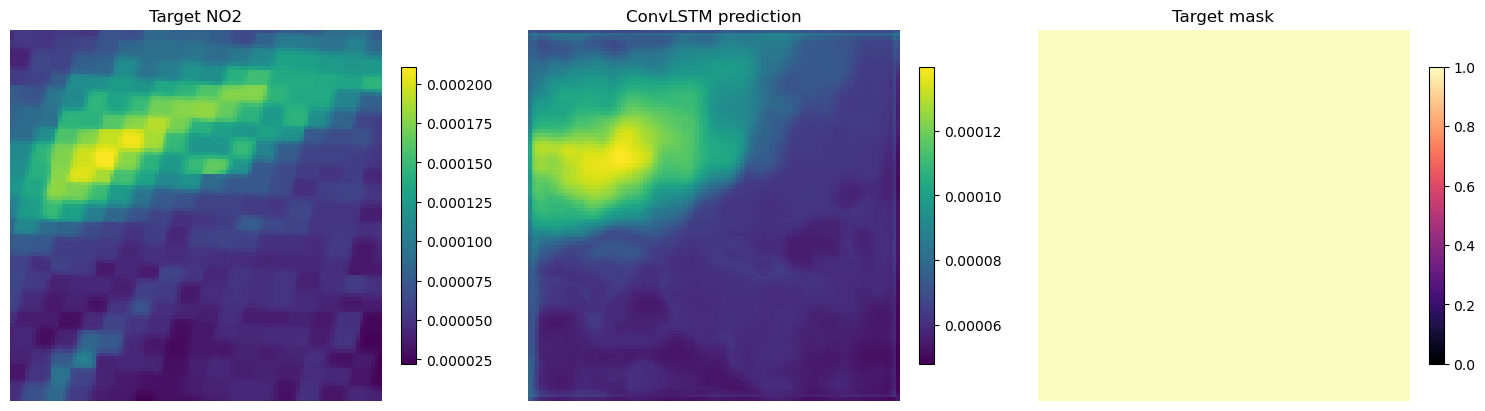

In [50]:
if convlstm_best_state is not None:
    convlstm_model.load_state_dict(convlstm_best_state)

convlstm_history_df = pd.DataFrame(convlstm_history)
convlstm_history_df

convlstm_preds, convlstm_targets, convlstm_masks, convlstm_test_mae, convlstm_test_rmse = evaluate_on_loader(
    convlstm_model,
    convlstm_test_loader,
    train_mean,
    train_std,
)
print(f"ConvLSTM Test MAE:  {convlstm_test_mae:.4f}")
print(f"ConvLSTM Test RMSE: {convlstm_test_rmse:.4f}")

convlstm_sample_index = randint(0, len(convlstm_test_dataset) - 1)
convlstm_sample_seq, convlstm_sample_target, convlstm_sample_mask = convlstm_test_dataset[convlstm_sample_index]
with torch.no_grad():
    convlstm_sample_pred = convlstm_model(convlstm_sample_seq.unsqueeze(0).to(device)).cpu().squeeze(0).squeeze(0)

convlstm_sample_target = convlstm_sample_target.squeeze(0) * train_std + train_mean
convlstm_sample_prediction = convlstm_sample_pred * train_std + train_mean
convlstm_sample_mask_2d = convlstm_sample_mask.squeeze(0)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)

im0 = axes[0].imshow(convlstm_sample_target.numpy(), cmap="viridis")
axes[0].set_title("Target NO2")
axes[0].axis("off")

im1 = axes[1].imshow(convlstm_sample_prediction.numpy(), cmap="viridis")
axes[1].set_title("ConvLSTM prediction")
axes[1].axis("off")

im2 = axes[2].imshow(convlstm_sample_mask_2d.numpy(), cmap="magma", vmin=0, vmax=1)
axes[2].set_title("Target mask")
axes[2].axis("off")

fig.colorbar(im0, ax=axes[0], shrink=0.8)
fig.colorbar(im1, ax=axes[1], shrink=0.8)
fig.colorbar(im2, ax=axes[2], shrink=0.8)
plt.show()

if not convlstm_history_df.empty:
    plt.figure(figsize=(8, 4))
    plt.plot(convlstm_history_df["epoch"], convlstm_history_df["train_loss"], label="train")
    plt.plot(convlstm_history_df["epoch"], convlstm_history_df["val_loss"], label="val")
    plt.xlabel("Epoch")
    plt.ylabel("Masked MSE")
    plt.title("ConvLSTM training curve")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

# Unet Encoder-Decoder

We can also try a UNet-style encoder-decoder architecture, which is effective for image-to-image tasks. The encoder captures spatial features at multiple scales, while the decoder reconstructs the output grid. Skip connections help preserve spatial details, which is important for accurate NO2 predictions.

MaskAwareUNet(
  (inc): DoubleConv(
    (block): Sequential(
      (0): Conv2d(14, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (down1): DownBlock(
    (block): Sequential(
      (0): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (1): DoubleConv(
        (block): Sequential(
          (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
          (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, a

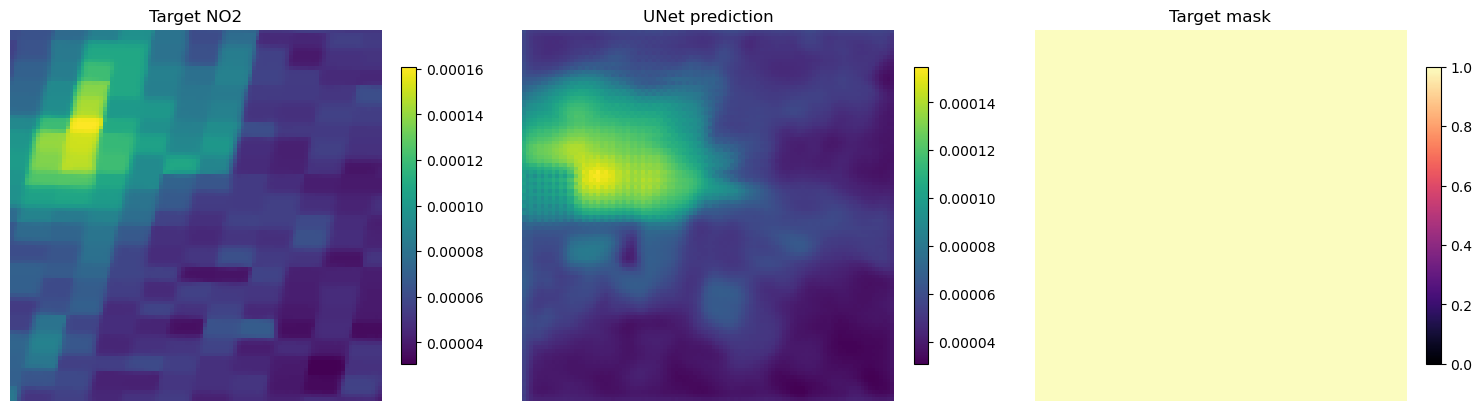

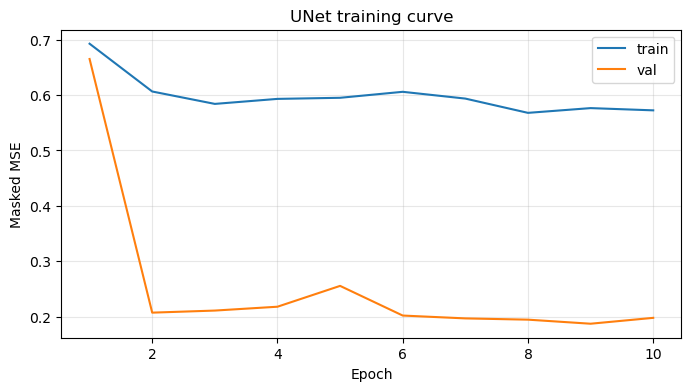

In [ ]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class DownBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.MaxPool2d(kernel_size=2),
            DoubleConv(in_channels, out_channels),
        )

    def forward(self, x):
        return self.block(x)


class UpBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_channels, in_channels // 2, kernel_size=2, stride=2)
        self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x, skip_connection):
        x = self.up(x)
        height_diff = skip_connection.size(2) - x.size(2)
        width_diff = skip_connection.size(3) - x.size(3)

        x = nn.functional.pad(
            x,
            [
                width_diff // 2,
                width_diff - width_diff // 2,
                height_diff // 2,
                height_diff - height_diff // 2,
            ],
        )
        x = torch.cat([skip_connection, x], dim=1)
        return self.conv(x)


class MaskAwareUNet(nn.Module):
    def __init__(self, in_channels, base_channels=32):
        super().__init__()
        self.inc = DoubleConv(in_channels, base_channels)
        self.down1 = DownBlock(base_channels, base_channels * 2)
        self.down2 = DownBlock(base_channels * 2, base_channels * 4)
        self.down3 = DownBlock(base_channels * 4, base_channels * 8)
        self.bottleneck = DownBlock(base_channels * 8, base_channels * 16)
        self.up1 = UpBlock(base_channels * 16, base_channels * 8)
        self.up2 = UpBlock(base_channels * 8, base_channels * 4)
        self.up3 = UpBlock(base_channels * 4, base_channels * 2)
        self.up4 = UpBlock(base_channels * 2, base_channels)
        self.outc = nn.Conv2d(base_channels, 1, kernel_size=1)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.bottleneck(x4)
        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)
        return self.outc(x)


unet_model = MaskAwareUNet(in_channels=lookback * 2, base_channels=32).to(device)
print(unet_model)

unet_optimizer = torch.optim.AdamW(unet_model.parameters(), lr=1e-3, weight_decay=1e-4)
unet_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(unet_optimizer, mode="min", patience=3, factor=0.5)

unet_best_val_loss = float("inf")
unet_best_state = None
unet_history = []
unet_num_epochs = 10

for epoch in range(1, unet_num_epochs + 1):
    unet_train_loss, unet_train_mae = run_epoch(unet_model, train_loader, optimizer=unet_optimizer)
    unet_val_loss, unet_val_mae = run_epoch(unet_model, val_loader)
    unet_scheduler.step(unet_val_loss)

    unet_history.append(
        {
            "epoch": epoch,
            "train_loss": unet_train_loss,
            "train_mae": unet_train_mae,
            "val_loss": unet_val_loss,
            "val_mae": unet_val_mae,
        }
    )

    if unet_val_loss < unet_best_val_loss:
        unet_best_val_loss = unet_val_loss
        unet_best_state = {key: value.detach().cpu().clone() for key, value in unet_model.state_dict().items()}

    print(
        f"Epoch {epoch:02d} | "
        f"train loss {unet_train_loss:.4f} | train mae {unet_train_mae:.4f} | "
        f"val loss {unet_val_loss:.4f} | val mae {unet_val_mae:.4f}"
    )

if unet_best_state is not None:
    unet_model.load_state_dict(unet_best_state)

unet_history_df = pd.DataFrame(unet_history)
unet_history_df

unet_preds, unet_targets, unet_masks, unet_test_mae, unet_test_rmse = evaluate_on_loader(
    unet_model,
    test_loader,
    train_std,
    train_mean,
)
print(f"UNet Test MAE:  {unet_test_mae:.4f}")
print(f"UNet Test RMSE: {unet_test_rmse:.4f}")


Unet Training

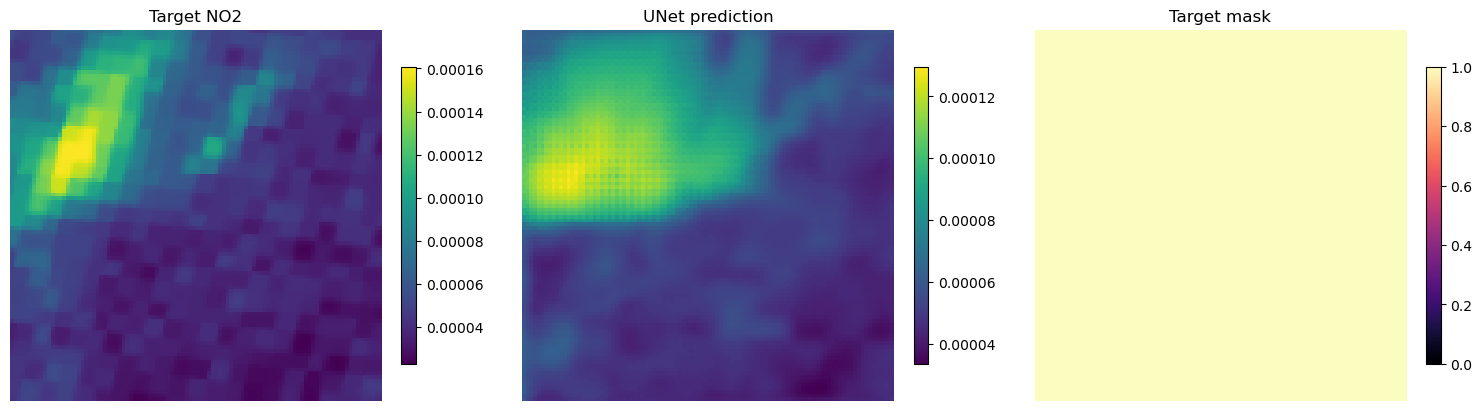

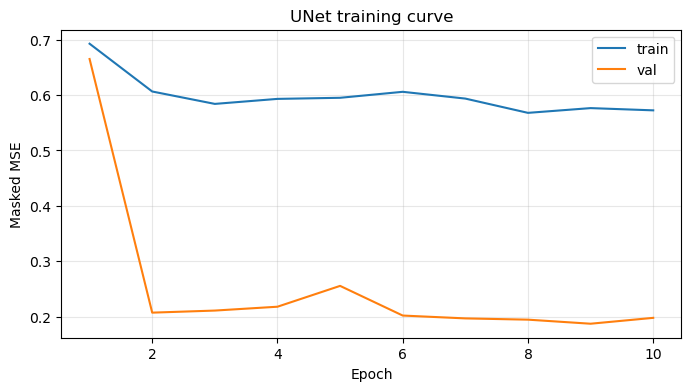

In [ ]:

unet_sample_index = randint(0, len(test_dataset) - 1)
unet_sample_x, unet_sample_y, unet_sample_mask = test_dataset[unet_sample_index]
with torch.no_grad():
    unet_sample_pred = unet_model(unet_sample_x.unsqueeze(0).to(device)).cpu().squeeze(0).squeeze(0)

unet_sample_target = unet_sample_y.squeeze(0) * train_std + train_mean
unet_sample_prediction = unet_sample_pred * train_std + train_mean
unet_sample_mask_2d = unet_sample_mask.squeeze(0)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)

im0 = axes[0].imshow(unet_sample_target.numpy(), cmap="viridis")
axes[0].set_title("Target NO2")
axes[0].axis("off")

im1 = axes[1].imshow(unet_sample_prediction.numpy(), cmap="viridis")
axes[1].set_title("UNet prediction")
axes[1].axis("off")
from pathlib import Path
from random import randint
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

checkpoint_dir = Path(f"/storage/anwesha.ghosh_ug2023/ConvLSTM/{time.strftime('%Y%m%d_%H%M%S')}_convlstm_checkpoints")
if not checkpoint_dir.exists():
    checkpoint_dir.mkdir(parents=True, exist_ok=True)
best_checkpoint_path = checkpoint_dir / "convlstm_best.pt"
last_checkpoint_path = checkpoint_dir / "convlstm_last.pt"

regularized_path = Path("~/final/data/no2_regularized_100x100.npz")
if not regularized_path.exists():
    raise FileNotFoundError(f"Could not find {regularized_path}. Run the regularization cell first.")

with np.load(regularized_path, allow_pickle=True) as data:
    regularized_no2_tensor = data["grids"].astype(np.float32)
    regularized_no2_mask_tensor = data["masks"].astype(np.float32)
    regularized_dates = pd.to_datetime(data["datetime"])
    compressed_lat_axis = data["lat_axis"].astype(np.float32)
    compressed_lon_axis = data["lon_axis"].astype(np.float32)

print("Grid tensor shape:", regularized_no2_tensor.shape)
print("Mask tensor shape:", regularized_no2_mask_tensor.shape)
print("Date range:", regularized_dates.min(), "->", regularized_dates.max())
print("Latitude axis length:", len(compressed_lat_axis))
print("Longitude axis length:", len(compressed_lon_axis))


def masked_mean_std(grids, masks):
    observed_values = grids[masks > 0]
    if observed_values.size == 0:
        raise ValueError("No observed values found while computing normalization stats.")

    mean = float(observed_values.mean())
    std = float(observed_values.std())
    if std < 1e-6:
        std = 1.0
    return mean, std


def normalize_grid(grid, mean, std):
    normalized = (grid - mean) / std
    return np.nan_to_num(normalized, nan=0.0).astype(np.float32)


lookback = 7
num_days = len(regularized_no2_tensor)
if num_days <= lookback:
    raise ValueError(f"Need more than {lookback} daily grids to build temporal samples.")

train_fraction = 0.7
val_fraction = 0.15
train_end = max(lookback + 1, int(num_days * train_fraction))
val_end = max(train_end + 1, int(num_days * (train_fraction + val_fraction)))
val_end = min(val_end, num_days - 1)

train_mean, train_std = masked_mean_std(
    regularized_no2_tensor[:train_end],
    regularized_no2_mask_tensor[:train_end],
)
print(f"Training normalization mean: {train_mean:.4f}")
print(f"Training normalization std:  {train_std:.4f}")


all_target_indices = np.arange(lookback, num_days)
train_target_indices = all_target_indices[all_target_indices < train_end]
val_target_indices = all_target_indices[(all_target_indices >= train_end) & (all_target_indices < val_end)]
test_target_indices = all_target_indices[all_target_indices >= val_end]
batch_size = 16

class NO2TemporalSequenceDataset(Dataset):
    def __init__(self, grids, masks, dates, lookback, mean, std, target_indices):
        self.grids = grids
        self.masks = masks
        self.dates = dates
        self.lookback = lookback
        self.mean = mean
        self.std = std
        self.target_indices = target_indices

    def __len__(self):
        return len(self.target_indices)

    def __getitem__(self, idx):
        target_idx = self.target_indices[idx]
        start_idx = target_idx - self.lookback

        input_grids = np.nan_to_num(self.grids[start_idx:target_idx], nan=0.0).astype(np.float32)
        input_masks = np.nan_to_num(self.masks[start_idx:target_idx], nan=0.0).astype(np.float32)
        input_seq = np.stack([input_grids, input_masks], axis=1).astype(np.float32)

        if self.mean is not None and self.std is not None:
            input_seq[:, 0] = (input_seq[:, 0] - self.mean) / self.std

        target = np.nan_to_num(self.grids[target_idx][None, ...], nan=0.0).astype(np.float32)
        target_mask = np.nan_to_num(self.masks[target_idx][None, ...], nan=0.0).astype(np.float32)

        if self.mean is not None and self.std is not None:
            target = (target - self.mean) / self.std

        return (
            torch.from_numpy(input_seq),
            torch.from_numpy(target),
            torch.from_numpy(target_mask),
        )


convlstm_train_dataset = NO2TemporalSequenceDataset(
    regularized_no2_tensor,
    regularized_no2_mask_tensor,
    regularized_dates,
    lookback,
    train_mean,
    train_std,
    train_target_indices,
)
convlstm_val_dataset = NO2TemporalSequenceDataset(
    regularized_no2_tensor,
    regularized_no2_mask_tensor,
    regularized_dates,
    lookback,
    train_mean,
    train_std,
    val_target_indices,
)
convlstm_test_dataset = NO2TemporalSequenceDataset(
    regularized_no2_tensor,
    regularized_no2_mask_tensor,
    regularized_dates,
    lookback,
    train_mean,
    train_std,
    test_target_indices,
)

convlstm_train_loader = DataLoader(convlstm_train_dataset, batch_size=batch_size, shuffle=True)
convlstm_val_loader = DataLoader(convlstm_val_dataset, batch_size=batch_size, shuffle=False)
convlstm_test_loader = DataLoader(convlstm_test_dataset, batch_size=batch_size, shuffle=False)


class ConvLSTMCell(nn.Module):
    def __init__(self, input_dim, hidden_dim, kernel_size=3):
        super().__init__()
        padding = kernel_size // 2
        self.hidden_dim = hidden_dim
        self.gates = nn.Conv2d(input_dim + hidden_dim, 4 * hidden_dim, kernel_size, padding=padding)

    def forward(self, x, state):
        h_prev, c_prev = state
        combined = torch.cat([x, h_prev], dim=1)
        gates = self.gates(combined)
        input_gate, forget_gate, output_gate, candidate_gate = torch.chunk(gates, 4, dim=1)
        input_gate = torch.sigmoid(input_gate)
        forget_gate = torch.sigmoid(forget_gate)
        output_gate = torch.sigmoid(output_gate)
        candidate_gate = torch.tanh(candidate_gate)
        c_next = forget_gate * c_prev + input_gate * candidate_gate
        h_next = output_gate * torch.tanh(c_next)
        return h_next, c_next


class MaskAwareConvLSTM(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=32, kernel_size=3):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.cell = ConvLSTMCell(input_dim=input_dim, hidden_dim=hidden_dim, kernel_size=kernel_size)
        self.decoder = nn.Sequential(
            nn.Conv2d(hidden_dim, hidden_dim, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden_dim),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden_dim, hidden_dim // 2, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden_dim // 2),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden_dim // 2, 1, kernel_size=1),
        )

    def forward(self, x):
        if x.ndim != 5:
            raise ValueError("Expected input of shape [batch, time, channels, height, width].")

        batch_size, time_steps, _, height, width = x.shape
        h_state = torch.zeros(batch_size, self.hidden_dim, height, width, device=x.device, dtype=x.dtype)
        c_state = torch.zeros_like(h_state)

        for time_index in range(time_steps):
            h_state, c_state = self.cell(x[:, time_index], (h_state, c_state))

        return self.decoder(h_state)


convlstm_model = MaskAwareConvLSTM(input_dim=2, hidden_dim=32).to(device)
print(convlstm_model)

convlstm_sample_seq, convlstm_sample_target, convlstm_sample_mask = convlstm_train_dataset[0]
print("ConvLSTM sample shapes:", convlstm_sample_seq.shape, convlstm_sample_target.shape, convlstm_sample_mask.shape)


def masked_mse(prediction, target, target_mask, eps=1e-6):
    prediction = torch.nan_to_num(prediction)
    target = torch.nan_to_num(target)
    squared_error = (prediction - target) ** 2 * target_mask
    return squared_error.sum() / target_mask.sum().clamp_min(eps)


def run_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)

    total_loss = 0.0
    total_masked_mae = 0.0
    total_masked_points = 0.0

    for x, y, y_mask in loader:
        x = x.to(device)
        y = y.to(device)
        y_mask = y_mask.to(device)

        if is_train:
            optimizer.zero_grad(set_to_none=True)

        prediction = model(x)
        loss = masked_mse(prediction, y, y_mask)

        if is_train:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        with torch.no_grad():
            masked_abs_error = (prediction - y).abs() * y_mask
            batch_masked_points = y_mask.sum().item()
            total_loss += loss.item() * max(batch_masked_points, 1.0)
            total_masked_mae += masked_abs_error.sum().item()
            total_masked_points += batch_masked_points

    mean_loss = total_loss / max(total_masked_points, 1.0)
    mean_mae = total_masked_mae / max(total_masked_points, 1.0)
    return mean_loss, mean_mae


def evaluate_on_loader(model, loader, mean, std):
    model.eval()
    preds = []
    targets = []
    masks = []

    with torch.no_grad():
        for x, y, y_mask in loader:
            x = x.to(device)
            y = y.to(device)
            y_mask = y_mask.to(device)
            prediction = model(x)

            preds.append(prediction.cpu().numpy())
            targets.append(y.cpu().numpy())
            masks.append(y_mask.cpu().numpy())

    preds = np.concatenate(preds, axis=0)
    targets = np.concatenate(targets, axis=0)
    masks = np.concatenate(masks, axis=0)

    preds = preds * std + mean
    targets = targets * std + mean

    valid = masks > 0
    if not np.any(valid):
        raise ValueError("No valid target cells were found during evaluation.")

    mae = np.mean(np.abs(preds[valid] - targets[valid]))
    rmse = np.sqrt(np.mean((preds[valid] - targets[valid]) ** 2))
    return preds, targets, masks, mae, rmse


torch.manual_seed(42)
np.random.seed(42)

convlstm_optimizer = torch.optim.AdamW(convlstm_model.parameters(), lr=1e-3, weight_decay=1e-4)
convlstm_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    convlstm_optimizer,
    mode="min",
    patience=3,
    factor=0.5,
)

convlstm_best_val_loss = float("inf")
convlstm_best_state = None
convlstm_history = []
convlstm_num_epochs = 3

if last_checkpoint_path.exists():
    checkpoint = torch.load(last_checkpoint_path, map_location=device)
    convlstm_model.load_state_dict(checkpoint["model_state_dict"])
    convlstm_optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    convlstm_scheduler.load_state_dict(checkpoint["scheduler_state_dict"])
    convlstm_best_val_loss = checkpoint.get("best_val_loss", float("inf"))
    convlstm_history = checkpoint.get("history", [])
    print(f"Resumed training from {last_checkpoint_path}")

for epoch in range(1, convlstm_num_epochs + 1):
    convlstm_train_loss, convlstm_train_mae = run_epoch(
        convlstm_model,
        convlstm_train_loader,
        optimizer=convlstm_optimizer,
    )
    convlstm_val_loss, convlstm_val_mae = run_epoch(convlstm_model, convlstm_val_loader)
    convlstm_scheduler.step(convlstm_val_loss)

    convlstm_history.append(
        {
            "epoch": epoch,
            "train_loss": convlstm_train_loss,
            "train_mae": convlstm_train_mae,
            "val_loss": convlstm_val_loss,
            "val_mae": convlstm_val_mae,
        }
    )

    if convlstm_val_loss < convlstm_best_val_loss:
        convlstm_best_val_loss = convlstm_val_loss
        convlstm_best_state = {key: value.detach().cpu().clone() for key, value in convlstm_model.state_dict().items()}

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": convlstm_best_state,
                "optimizer_state_dict": convlstm_optimizer.state_dict(),
                "scheduler_state_dict": convlstm_scheduler.state_dict(),
                "best_val_loss": convlstm_best_val_loss,
                "history": convlstm_history,
                "train_mean": train_mean,
                "train_std": train_std,
                "lookback": lookback,
                "batch_size": batch_size,
            },
            best_checkpoint_path,
        )

    torch.save(
        {
            "epoch": epoch,
            "model_state_dict": convlstm_model.state_dict(),
            "optimizer_state_dict": convlstm_optimizer.state_dict(),
            "scheduler_state_dict": convlstm_scheduler.state_dict(),
            "best_val_loss": convlstm_best_val_loss,
            "history": convlstm_history,
            "train_mean": train_mean,
            "train_std": train_std,
            "lookback": lookback,
            "batch_size": batch_size,
        },
        last_checkpoint_path,
    )

    print(
        f"Epoch {epoch:02d} | "
        f"train loss {convlstm_train_loss:.4f} | train mae {convlstm_train_mae:.4f} | "
        f"val loss {convlstm_val_loss:.4f} | val mae {convlstm_val_mae:.4f}"
    )


if convlstm_best_state is not None:
    convlstm_model.load_state_dict(convlstm_best_state)
elif best_checkpoint_path.exists():
    checkpoint = torch.load(best_checkpoint_path, map_location=device)
    convlstm_model.load_state_dict(checkpoint["model_state_dict"])
    convlstm_best_val_loss = checkpoint.get("best_val_loss", convlstm_best_val_loss)

torch.save(
    {
        "model_state_dict": convlstm_model.state_dict(),
        "best_val_loss": convlstm_best_val_loss,
        "history": convlstm_history,
        "train_mean": train_mean,
        "train_std": train_std,
        "lookback": lookback,
        "batch_size": batch_size,
    },
    best_checkpoint_path,
)

convlstm_history_df = pd.DataFrame(convlstm_history)
convlstm_history_df

convlstm_preds, convlstm_targets, convlstm_masks, convlstm_test_mae, convlstm_test_rmse = evaluate_on_loader(
    convlstm_model,
    convlstm_test_loader,
    train_mean,
    train_std,
)
print(f"ConvLSTM Test MAE:  {convlstm_test_mae:.4f}")
print(f"ConvLSTM Test RMSE: {convlstm_test_rmse:.4f}")

# Show 8 random samples (target, prediction, mask) instead of a single one
num_samples = 8
indices = torch.randperm(len(convlstm_test_dataset))[:num_samples].tolist()

fig, axes = plt.subplots(3, num_samples, figsize=(3 * num_samples, 9), constrained_layout=True)
for col, idx in enumerate(indices):
    sample_seq, sample_target, sample_mask = convlstm_test_dataset[idx]
    with torch.no_grad():
        sample_pred = convlstm_model(sample_seq.unsqueeze(0).to(device)).cpu().squeeze(0).squeeze(0)

    sample_target = sample_target.squeeze(0) * train_std + train_mean
    sample_prediction = sample_pred * train_std + train_mean
    sample_mask_2d = sample_mask.squeeze(0)

    ax_t = axes[0, col]
    im_t = ax_t.imshow(sample_target.numpy(), cmap="viridis")
    ax_t.set_title(f"Target #{idx}")
    ax_t.axis("off")

    ax_p = axes[1, col]
    im_p = ax_p.imshow(sample_prediction.numpy(), cmap="viridis")
    ax_p.set_title("Prediction")
    ax_p.axis("off")

    ax_m = axes[2, col]
    im_m = ax_m.imshow(sample_mask_2d.numpy(), cmap="magma", vmin=0, vmax=1)
    ax_m.set_title("Mask")
    ax_m.axis("off")

    fig.colorbar(im_t, ax=ax_t, shrink=0.6)
    fig.colorbar(im_p, ax=ax_p, shrink=0.6)
    fig.colorbar(im_m, ax=ax_m, shrink=0.6)

# Save the multi-sample plot
plot_path = checkpoint_dir / "sample_predictions_8.png"
plt.savefig(plot_path)
plt.close()



if not convlstm_history_df.empty:
    plt.figure(figsize=(8, 4))
    plt.plot(convlstm_history_df["epoch"], convlstm_history_df["train_loss"], label="train")
    plt.plot(convlstm_history_df["epoch"], convlstm_history_df["val_loss"], label="val")
    plt.xlabel("Epoch")
    plt.ylabel("Masked MSE")
    plt.title("ConvLSTM training curve")
    plt.legend()
    plt.grid(alpha=0.3)
    # Save the second plot (training curve) instead of showing it
    training_curve_path = checkpoint_dir / "training_curve_epoch_loss.png"
    plt.savefig(training_curve_path)
    plt.close()


im2 = axes[2].imshow(unet_sample_mask_2d.numpy(), cmap="magma", vmin=0, vmax=1)
axes[2].set_title("Target mask")
axes[2].axis("off")

fig.colorbar(im0, ax=axes[0], shrink=0.8)
fig.colorbar(im1, ax=axes[1], shrink=0.8)
fig.colorbar(im2, ax=axes[2], shrink=0.8)
plt.show()

if not unet_history_df.empty:
    plt.figure(figsize=(8, 4))
    plt.plot(unet_history_df["epoch"], unet_history_df["train_loss"], label="train")
    plt.plot(unet_history_df["epoch"], unet_history_df["val_loss"], label="val")
    plt.xlabel("Epoch")
    plt.ylabel("Masked MSE")
    plt.title("UNet training curve")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

# Weather aware model

We first create a dataset which has Temperature and weather as seperate tensors. the shapes of these are below.

We eventually ant to use this in tandem with our unet, where the encoded weather and temperature features are concatenated with the encoded NO2 features before being passed to the decoder. This way, the model can learn to leverage weather and temperature information to improve NO2 predictions.

In [28]:
from pathlib import Path

import numpy as np
import pandas as pd
from tqdm.auto import tqdm


regularized_path = Path("./data/no2_regularized_200x200.npz")

with np.load(regularized_path, allow_pickle=True) as data:
    regularized_no2_tensor = data["grids"].astype(np.float32)
    regularized_no2_mask_tensor = data["masks"].astype(np.float32)
    regularized_dates = pd.to_datetime(data["datetime"]).normalize()
    no2_lat_axis = data["lat_axis"]
    no2_lon_axis = data["lon_axis"]

print(f"Loaded NO2 regularized tensor from {regularized_path}")
print("NO2 grids shape:", regularized_no2_tensor.shape)
print("NO2 masks shape:", regularized_no2_mask_tensor.shape)
print("NO2 dates shape:", regularized_dates.shape)
print("NO2 latitude axis length:", len(no2_lat_axis))
print("NO2 longitude axis length:", len(no2_lon_axis))

regularized_no2_df = pd.DataFrame(
    {
        "datetime": pd.Series(regularized_dates, dtype="datetime64[ns]"),
        "no2_day": pd.Series(list(regularized_no2_tensor), dtype="object"),
        "no2_mask": pd.Series(list(regularized_no2_mask_tensor), dtype="object"),
    }
)

wind_u = pd.read_csv("./data/WIND_U_manual_27929m.csv")
wind_v = pd.read_csv("./data/WIND_V_manual_27929m.csv")
temp = pd.read_csv("./data/TEMP_manual_27929m.csv")

for weather_df in (wind_u, wind_v, temp):
    weather_df["timestamp"] = pd.to_datetime(weather_df["timestamp"], errors="coerce")
    weather_df["day"] = weather_df["timestamp"].dt.normalize()
    weather_df["hour"] = weather_df["timestamp"].dt.hour

weather_lat_axis = np.sort(temp["latitude"].dropna().unique())
weather_lon_axis = np.sort(temp["longitude"].dropna().unique())
print("Weather grid shape:", (len(weather_lat_axis), len(weather_lon_axis)))
print("Weather hourly timestamps per day in temp:", temp.groupby("day")["hour"].nunique().dropna().head().to_dict())


def build_hourly_tensor(day_frame, value_col, lat_axis, lon_axis):
    hourly_grids = []
    for hour in range(24):
        hour_frame = day_frame.loc[day_frame["hour"] == hour, ["latitude", "longitude", value_col]]
        if hour_frame.empty:
            raise ValueError(f"No {value_col} data found for hour {hour} on day {day_frame['day'].iloc[0].date()}.")

        hour_grid = (
            hour_frame.pivot_table(
                index="latitude",
                columns="longitude",
                values=value_col,
                aggfunc="mean",
            )
            .reindex(index=lat_axis, columns=lon_axis)
            .astype(np.float32)
            .ffill(axis=0)
            .bfill(axis=0)
            .ffill(axis=1)
            .bfill(axis=1)
        )
        hourly_grids.append(np.nan_to_num(hour_grid.to_numpy(dtype=np.float32), nan=0.0))

    return np.stack(hourly_grids, axis=0)


def build_weather_sequences(day):
    temp_day = temp.loc[temp["day"] == day]
    wind_u_day = wind_u.loc[wind_u["day"] == day]
    wind_v_day = wind_v.loc[wind_v["day"] == day]

    if temp_day.empty or wind_u_day.empty or wind_v_day.empty:
        raise ValueError(f"Missing weather data for {day.date()}.")

    temp_seq = build_hourly_tensor(temp_day, "TEMP", weather_lat_axis, weather_lon_axis)[:, np.newaxis, :, :]
    wind_u_seq = build_hourly_tensor(wind_u_day, "WIND_U", weather_lat_axis, weather_lon_axis)
    wind_v_seq = build_hourly_tensor(wind_v_day, "WIND_V", weather_lat_axis, weather_lon_axis)
    wind_seq = np.stack([wind_u_seq, wind_v_seq], axis=1)
    return temp_seq.astype(np.float32), wind_seq.astype(np.float32)


preview_rows = []
for row in regularized_no2_df.head(3).itertuples(index=False):
    input_day = pd.Timestamp(row.datetime).normalize()
    target_day = input_day + pd.Timedelta(days=1)
    target_idx = np.where(regularized_dates == target_day)[0]
    if len(target_idx) == 0:
        continue

    temp_seq, wind_seq = build_weather_sequences(target_day)
    preview_rows.append(
        {
            "datetime": input_day,
            "no2_day": row.no2_day[np.newaxis, ...].astype(np.float32),
            "no2_mask": row.no2_mask[np.newaxis, ...].astype(np.float32),
            "temp_seq": temp_seq,
            "wind_seq": wind_seq,
            "next_no2": regularized_no2_tensor[target_idx[0]][np.newaxis, ...].astype(np.float32),
        }
    )

preview_df = pd.DataFrame.from_records(preview_rows)
print("\nPreview row shapes:")
if preview_df.empty:
    print("No aligned preview rows found.")
else:
    first_row = preview_df.iloc[0]
    print("no2_day:", first_row["no2_day"].shape)
    print("no2_mask:", first_row["no2_mask"].shape)
    print("temp_seq:", first_row["temp_seq"].shape)
    print("wind_seq:", first_row["wind_seq"].shape)
    print("next_no2:", first_row["next_no2"].shape)
    print("no2_day min/max:", float(first_row["no2_day"].min()), float(first_row["no2_day"].max()))
    print("temp_seq min/max:", float(first_row["temp_seq"].min()), float(first_row["temp_seq"].max()))
    print("wind_seq min/max:", float(first_row["wind_seq"].min()), float(first_row["wind_seq"].max()))

aligned_rows = []

for row in tqdm(regularized_no2_df.itertuples(index=False), total=len(regularized_no2_df), desc="Building aligned rows"):
    input_day = pd.Timestamp(row.datetime).normalize()
    target_day = input_day + pd.Timedelta(days=1)
    target_idx = np.where(regularized_dates == target_day)[0]
    if len(target_idx) == 0:
        continue

    temp_seq, wind_seq = build_weather_sequences(target_day)
    aligned_rows.append(
        {
            "datetime": np.datetime64(input_day),
            "no2_day": row.no2_day[np.newaxis, ...].astype(np.float32),
            "no2_mask": row.no2_mask[np.newaxis, ...].astype(np.float32),
            "temp_seq": temp_seq.astype(np.float32),
            "wind_seq": wind_seq.astype(np.float32),
            "next_no2": regularized_no2_tensor[target_idx[0]][np.newaxis, ...].astype(np.float32),
        }
    )

if not aligned_rows:
    raise ValueError("No aligned rows found.")

output_path = Path("./data/weather_preview_full.npz")
np.savez_compressed(
    output_path,
    datetime=np.array([row["datetime"] for row in aligned_rows], dtype="datetime64[ns]"),
    no2_day=np.stack([row["no2_day"] for row in aligned_rows], axis=0),
    no2_mask=np.stack([row["no2_mask"] for row in aligned_rows], axis=0),
    temp_seq=np.stack([row["temp_seq"] for row in aligned_rows], axis=0),
    wind_seq=np.stack([row["wind_seq"] for row in aligned_rows], axis=0),
    next_no2=np.stack([row["next_no2"] for row in aligned_rows], axis=0),
    lat_axis=weather_lat_axis.astype(np.float32),
    lon_axis=weather_lon_axis.astype(np.float32),
)


print(f"Saved to {output_path}")

Loaded NO2 regularized tensor from data/no2_regularized_200x200.npz
NO2 grids shape: (2047, 200, 200)
NO2 masks shape: (2047, 200, 200)
NO2 dates shape: (2047,)
NO2 latitude axis length: 200
NO2 longitude axis length: 200
Weather grid shape: (4, 4)
Weather hourly timestamps per day in temp: {Timestamp('2019-01-01 00:00:00'): 24, Timestamp('2019-01-02 00:00:00'): 24, Timestamp('2019-01-03 00:00:00'): 24, Timestamp('2019-01-04 00:00:00'): 24, Timestamp('2019-01-05 00:00:00'): 24}

Preview row shapes:
no2_day: (1, 200, 200)
no2_mask: (1, 200, 200)
temp_seq: (24, 1, 4, 4)
wind_seq: (24, 2, 4, 4)
next_no2: (1, 200, 200)
no2_day min/max: 6.220483919605613e-05 0.0008733879658393562
temp_seq min/max: 280.58514404296875 295.87548828125
wind_seq min/max: -2.434816598892212 1.9820984601974487


Building aligned rows:   0%|          | 0/2047 [00:00<?, ?it/s]

Saved to data/weather_preview_full.npz


In [29]:
weather_path = Path("./data/weather_preview_full.npz")

with np.load(weather_path, allow_pickle=True) as data:
    weather_preview_full_df = pd.DataFrame(
        {
            "datetime": pd.to_datetime(data["datetime"]),
            "no2_day": list(data["no2_day"]),
            "no2_mask": list(data["no2_mask"]),
            "temp_seq": list(data["temp_seq"]),
            "wind_seq": list(data["wind_seq"]),
            "next_no2": list(data["next_no2"]),
        }
    )

print(f"Number of lines: {len(weather_preview_full_df)}")
weather_preview_full_df.head()

Number of lines: 1940


,datetime,no2_day,no2_mask,temp_seq,wind_seq,next_no2
0,2019-01-01,"[[[0.000102101694, 9.498377e-05, 8.53256e-05, ...","[[[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0...","[[[[283.73917 282.6749 281.25763 281.0504 ], ...",[[[[-0.5083746 -1.4509374 -1.7945861 -1.699806...,"[[[4.2139814e-05, 3.9765146e-05, 3.6543006e-05..."
1,2019-01-02,"[[[4.2139814e-05, 3.9765146e-05, 3.6543006e-05...","[[[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0...","[[[[281.5509 281.1236 280.8283 280.88275], ...","[[[[1.8231195 1.6542406 1.7217922 1.8249619], ...","[[[5.6902794e-05, 5.9230402e-05, 6.238868e-05,..."
2,2019-01-05,"[[[5.1588722e-05, 5.282253e-05, 5.449665e-05, ...","[[[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0...","[[[[284.71628 284.47018 283.8737 283.63037], ...",[[[[ 0.88974524 -0.01307502 -1.36597 -1.900...,"[[[nan, nan, nan, nan, nan, nan, nan, nan, nan..."
3,2019-01-06,"[[[nan, nan, nan, nan, nan, nan, nan, nan, nan...","[[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0...","[[[[282.32678 282.32397 282.00833 282.231 ], ...",[[[[1.7116936 1.2133404 0.7741368 0.3553296...,"[[[4.7628342e-05, 5.4537377e-05, 6.3912106e-05..."
4,2019-01-07,"[[[4.7628342e-05, 5.4537377e-05, 6.3912106e-05...","[[[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0...","[[[[282.72803 282.50766 282.40634 282.53503], ...","[[[[1.8094211 1.6582711 1.73124 1.8380873], ...","[[[7.2763825e-05, 6.478521e-05, 6.478521e-05, ..."


In [ ]:
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


class WeatherAwareNO2Dataset(Dataset):
    def __init__(self, frame):
        self.frame = frame.reset_index(drop=True)

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, index):
        row = self.frame.iloc[index]
        x = {
            "no2_day": torch.from_numpy(row["no2_day"]),
            "no2_mask": torch.from_numpy(row["no2_mask"]),
            "temp_seq": torch.from_numpy(row["temp_seq"]),
            "wind_seq": torch.from_numpy(row["wind_seq"]),
        }
        y = {
            "next_no2": torch.from_numpy(row["next_no2"]),
        }
        return x, y


class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class DownBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.MaxPool2d(kernel_size=2),
            DoubleConv(in_channels, out_channels),
        )

    def forward(self, x):
        return self.block(x)


class UpBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_channels, in_channels // 2, kernel_size=2, stride=2)
        self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x, skip_connection):
        x = self.up(x)
        height_diff = skip_connection.size(2) - x.size(2)
        width_diff = skip_connection.size(3) - x.size(3)
        x = nn.functional.pad(
            x,
            [
                width_diff // 2,
                width_diff - width_diff // 2,
                height_diff // 2,
                height_diff - height_diff // 2,
            ],
        )
        x = torch.cat([skip_connection, x], dim=1)
        return self.conv(x)


class WeatherTemporalEncoder(nn.Module):
    def __init__(self, in_channels, embedding_dim=128):
        super().__init__()
        self.backbone = nn.Sequential(
            nn.Conv3d(in_channels, 32, kernel_size=3, padding=1),
            nn.BatchNorm3d(32),
            nn.ReLU(inplace=True),
            nn.Conv3d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm3d(64),
            nn.ReLU(inplace=True),
            nn.Conv3d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm3d(128),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool3d((1, 1, 1)),
        )
        self.projection = nn.Linear(128, embedding_dim)

    def forward(self, x):
        if x.ndim != 5:
            raise ValueError("Expected weather sequence with shape [batch, time, channels, height, width].")
        x = x.permute(0, 2, 1, 3, 4)
        features = self.backbone(x).flatten(1)
        return self.projection(features)


class WeatherAwareNO2FusionNet(nn.Module):
    def __init__(self, no2_channels=2, weather_embedding_dim=128, base_channels=32):
        super().__init__()
        self.inc = DoubleConv(no2_channels, base_channels)
        self.down1 = DownBlock(base_channels, base_channels * 2)
        self.down2 = DownBlock(base_channels * 2, base_channels * 4)
        self.down3 = DownBlock(base_channels * 4, base_channels * 8)
        self.bottleneck = DoubleConv(base_channels * 8, base_channels * 16)
        self.temp_encoder = WeatherTemporalEncoder(in_channels=1, embedding_dim=weather_embedding_dim)
        self.wind_encoder = WeatherTemporalEncoder(in_channels=2, embedding_dim=weather_embedding_dim)
        self.weather_fuse = nn.Sequential(
            nn.Linear(weather_embedding_dim * 2, weather_embedding_dim * 2),
            nn.ReLU(inplace=True),
            nn.Linear(weather_embedding_dim * 2, base_channels * 16),
        )
        self.up1 = UpBlock(base_channels * 16, base_channels * 8)
        self.up2 = UpBlock(base_channels * 8, base_channels * 4)
        self.up3 = UpBlock(base_channels * 4, base_channels * 2)
        self.up4 = UpBlock(base_channels * 2, base_channels)
        self.outc = nn.Conv2d(base_channels, 1, kernel_size=1)

    def forward(self, inputs):
        no2_day = inputs["no2_day"]
        no2_mask = inputs["no2_mask"]
        temp_seq = inputs["temp_seq"]
        wind_seq = inputs["wind_seq"]

        x = torch.cat([no2_day, no2_mask], dim=1)
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        bottleneck = self.bottleneck(x4)

        temp_embedding = self.temp_encoder(temp_seq)
        wind_embedding = self.wind_encoder(wind_seq)
        weather_embedding = torch.cat([temp_embedding, wind_embedding], dim=1)
        weather_bias = self.weather_fuse(weather_embedding).unsqueeze(-1).unsqueeze(-1)
        bottleneck = bottleneck + weather_bias

        x = self.up1(bottleneck, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)
        return self.outc(x)


def masked_mse(prediction, target, target_mask, eps=1e-6):
    squared_error = (prediction - target) ** 2 * target_mask
    return squared_error.sum() / target_mask.sum().clamp_min(eps)


if preview_df.empty:
    raise ValueError("preview_df is empty, so the model cannot be smoke-tested.")

preview_dataset = WeatherAwareNO2Dataset(preview_df)
preview_loader = DataLoader(preview_dataset, batch_size=2, shuffle=False)
inputs, targets = next(iter(preview_loader))
inputs = {key: value.to(device) for key, value in inputs.items()}
targets = {key: value.to(device) for key, value in targets.items()}

model = WeatherAwareNO2FusionNet().to(device)
with torch.no_grad():
    prediction = model(inputs)

print(model)
print("Input shapes:")
print("no2_day:", tuple(inputs["no2_day"].shape))
print("no2_mask:", tuple(inputs["no2_mask"].shape))
print("temp_seq:", tuple(inputs["temp_seq"].shape))
print("wind_seq:", tuple(inputs["wind_seq"].shape))
print("Prediction shape:", tuple(prediction.shape))
print("Target shape:", tuple(targets["next_no2"].shape))
print("Masked MSE on preview batch:", float(masked_mse(prediction, targets["next_no2"], torch.ones_like(targets["next_no2"])).item()))
